<div style="background: linear-gradient(135deg, #0A1628 0%, #028090 100%); padding: 40px; border-radius: 12px; color: white; text-align: center; margin-bottom: 20px;">
  <h1 style="margin:0; font-size: 2.2em; font-weight: 700;">🏦 NexaVault Financial Corp</h1>
  <h2 style="margin: 10px 0 5px; font-size: 1.4em; font-weight: 400; opacity: 0.9;">Intelligent Loan Approval System</h2>
  <p style="margin: 5px 0; opacity: 0.75; font-size: 1em;">End-to-End Machine Learning Pipeline — v5.0</p>
  <hr style="border-color: rgba(255,255,255,0.2); margin: 15px 0;">
  <p style="margin: 0; font-size: 0.9em; opacity: 0.7;">
    <strong>Author:</strong> Mandeep Sharma &nbsp;|&nbsp;
    <strong>Copyright © 2026 Mandeep Sharma. All rights reserved.</strong>
  </p>
</div>

## 📋 Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Setup & Imports](#1) | Libraries, configuration, constants |
| 2 | [Data Loading & Overview](#2) | Load dataset, shape, dtypes, first look |
| 3 | [Exploratory Data Analysis](#3) | Distributions, correlations, approval patterns |
| 4 | [Feature Engineering](#4) | Derived features, encoding maps, ratios |
| 5 | [Data Preprocessing](#5) | Sklearn pipeline, imputation, scaling |
| 6 | [Model Training](#6) | 4 candidates, 5-fold CV, hyperparameters |
| 7 | [Model Evaluation](#7) | ROC-AUC, confusion matrix, classification report |
| 8 | [Feature Importance](#8) | Top predictors, SHAP-style analysis |
| 9 | [Hard Underwriting Rules](#9) | Business logic gates, real lending standards |
| 10 | [Live Inference](#10) | Predict on new applicants, interest rate calculator |
| 11 | [Enhancements & Ideas](#11) | Advanced analyses, next steps, research directions |

---

### 🎯 Problem Statement

NexaVault Financial Corp processes thousands of loan applications daily across its branch and online channels. The legacy **manual review process** has three critical failures:

| Problem | Business Impact |
|---------|----------------|
| Takes 3–5 business days per application | Customer churn to faster competitors |
| Inconsistent officer decisions | Regulatory compliance risk |
| Creditworthy applicants rejected (~12%) | Direct revenue loss |
| High-risk applicants approved | Default losses, write-offs |

**Goal:** Build an AI-powered loan approval system that makes accurate, fast, and unbiased decisions — reducing review time from days to milliseconds while improving decision quality.

---

### 🏗️ Solution Architecture

```
Raw Application Data
        │
        ▼
┌─────────────────┐
│  Hard Rules     │  ← 9 underwriting gates (DTI, credit floors, bankruptcy)
│  (Business      │    These run FIRST — no ML model can override them
│   Logic Gates)  │
└────────┬────────┘
         │  Only applications passing ALL gates reach the ML model
         ▼
┌─────────────────┐
│  Feature        │  ← 22 engineered features from 24 raw inputs
│  Engineering    │    DTI ratio, Income/EMI ratio, log transforms
└────────┬────────┘
         ▼
┌─────────────────┐
│  ML Pipeline    │  ← Sklearn ColumnTransformer + best model
│  (Gradient      │    Trained on 2,000 historical applications
│   Boosting)     │    99.77% ROC-AUC on holdout test set
└────────┬────────┘
         ▼
  Decision + Rate + Risk Level
```

---
<a id="1"></a>
## 1. 🔧 Setup & Imports

We use a standard ML stack:
- **pandas / numpy** — data manipulation
- **scikit-learn** — preprocessing, pipelines, models, metrics
- **matplotlib / seaborn** — visualization
- **joblib** — model serialization

> 💡 All imports are at the top for reproducibility. The random seed (42) ensures results are identical on every run.

In [1]:
# ── Standard library ─────────────────────────────────────────────────────
import os
import warnings
import pathlib

# ── Data manipulation ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Machine learning — preprocessing ─────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer

# ── Machine learning — models ─────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC

# ── Machine learning — metrics ────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# ── Model persistence ─────────────────────────────────────────────────────
import joblib

# ── Global settings ───────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
np.random.seed(42)

# Plot style
plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         11,
})
sns.set_palette("husl")

# Paths
BASE_DIR   = pathlib.Path(".")
DATA_DIR   = BASE_DIR / "data"
MODEL_DIR  = BASE_DIR / "app"

# Project metadata
COMPANY    = "NexaVault Financial Corp"
COPYRIGHT  = "Copyright © 2026 Mandeep Sharma. All rights reserved."
VERSION    = "5.0.0"

print(f"✓ All libraries imported successfully")
print(f"✓ {COMPANY} — Loan Approval System v{VERSION}")
print(f"✓ {COPYRIGHT}")
print(f"✓ NumPy {np.__version__} | Pandas {pd.__version__}")

# ── Create output directories ─────────────────────────────────────────────
# The notebook saves all plots to docs/ — create it if it doesn't exist
os.makedirs("docs", exist_ok=True)
os.makedirs("app",  exist_ok=True)
os.makedirs("data", exist_ok=True)

print(f"✓ All libraries imported successfully")
print(f"✓ {COMPANY} — Loan Approval System v{VERSION}")
print(f"✓ {COPYRIGHT}")
print(f"✓ NumPy {np.__version__} | Pandas {pd.__version__}")
print(f"✓ Output directories ready: docs/, app/, data/")

✓ All libraries imported successfully
✓ NexaVault Financial Corp — Loan Approval System v5.0.0
✓ Copyright © 2026 Mandeep Sharma. All rights reserved.
✓ NumPy 2.4.3 | Pandas 3.0.1
✓ All libraries imported successfully
✓ NexaVault Financial Corp — Loan Approval System v5.0.0
✓ Copyright © 2026 Mandeep Sharma. All rights reserved.
✓ NumPy 2.4.3 | Pandas 3.0.1
✓ Output directories ready: docs/, app/, data/


---
<a id="2"></a>
## 2. 📂 Data Loading & Overview

### Dataset Description

The training dataset contains **2,000 historical loan applications** with 25 columns covering:
- **Demographics:** Gender, Marital Status, Dependents, Education, Citizenship
- **Employment:** Status (9 types), Job Tenure, Industry
- **Income:** Applicant, Co-applicant, Other income sources
- **Debt:** Monthly obligations (granular: $0 to $10,000)
- **Credit Profile:** Experian 7-tier model, utilization, late payments, bankruptcy
- **Loan Details:** Type (8), Purpose (8), Amount, Term, Down payment, Collateral
- **Target:** Loan_Status → Approved / Manual Review / Rejected

> 💡 Loan amounts are **independent** of income — a key design decision. In the real world, applicants choose the loan amount they want; income then determines whether they can afford it. An earlier version incorrectly derived loan amounts from income, causing the model to learn the wrong direction.

In [2]:
# ── Load training data ───────────────────────────────────────────────────
# Try DATA_DIR first; fall back to current directory if running from notebooks/ subfolder
import os as _os
_data_path = DATA_DIR / "train_applications.csv"
if not _data_path.exists():
    _data_path = pathlib.Path("../data/train_applications.csv")
if not _data_path.exists():
    _data_path = pathlib.Path("data/train_applications.csv")

df = pd.read_csv(_data_path)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage:  {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"Loaded from:   {_data_path}")
print()

# ── Quick overview ────────────────────────────────────────────────────────
df.head()

Dataset shape: 2,000 rows × 25 columns
Memory usage:  1768.5 KB
Loaded from:   data/train_applications.csv



,Loan_ID,Gender,Marital_Status,Dependents,Education,Employment_Status,Job_Tenure,Industry,Applicant_Annual_Income,CoApplicant_Annual_Income,...,Late_Payments_2yr,Credit_Utilization_Pct,Loan_Type,Loan_Purpose,Loan_Amount_K,Loan_Term_Months,Down_Payment_Pct,Property_Area,Collateral,Loan_Status
0,NV0000001,Male,Single,1,Bachelor's Degree,Business Owner,2-5 years,Manufacturing,40155,0,...,3,65,Home Purchase,Vacation Home,10,60,20.0,Rural,Vehicle,Rejected
1,NV0000002,Non-binary,Single,2,High School,Independent Contractor,2-5 years,Education,34404,0,...,0,20,Home Purchase,Home Improvement,800,360,10.0,Semiurban,Real Estate,Rejected
2,NV0000003,Female,Divorced,2,Master's Degree,Full-time Employee,1-2 years,Government,44772,0,...,0,45,Personal Loan,Business Capital,100,360,20.0,Suburban,Real Estate,Rejected
3,NV0000004,Female,Single,0,Bachelor's Degree,Retired,5-10 years,Finance,51547,0,...,0,5,Home Purchase,Investment Property,50,360,20.0,Rural,Vehicle,Approved
4,NV0000005,Male,Single,0,High School,Self-Employed,2-5 years,Retail,94188,0,...,1,45,Debt Consolidation,Medical,15,120,20.0,Urban,Business Assets,Approved


In [3]:
# ── Data types and non-null counts ────────────────────────────────────────
print("=== Column Info ===")
print(df.dtypes.to_string())
print()
print(f"\n=== Missing Values ===")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values — dataset is complete")
else:
    print(missing[missing > 0])

=== Column Info ===
Loan_ID                          str
Gender                           str
Marital_Status                   str
Dependents                     int64
Education                        str
Employment_Status                str
Job_Tenure                       str
Industry                         str
Applicant_Annual_Income        int64
CoApplicant_Annual_Income      int64
Other_Income                   int64
Monthly_Debt_Obligations       int64
Credit_Tier                      str
Credit_Score                   int64
Bankruptcy_History               str
Late_Payments_2yr              int64
Credit_Utilization_Pct         int64
Loan_Type                        str
Loan_Purpose                     str
Loan_Amount_K                  int64
Loan_Term_Months               int64
Down_Payment_Pct             float64
Property_Area                    str
Collateral                       str
Loan_Status                      str


=== Missing Values ===
Bankruptcy_History    1746
dty

In [4]:
# ── Statistical summary ──────────────────────────────────────────────────
print("=== Numerical Features — Statistical Summary ===\n")
num_cols = ["Applicant_Annual_Income","CoApplicant_Annual_Income","Other_Income",
            "Monthly_Debt_Obligations","Credit_Score","Late_Payments_2yr",
            "Credit_Utilization_Pct","Loan_Amount_K","Loan_Term_Months","Down_Payment_Pct"]
df[num_cols].describe().round(2)

=== Numerical Features — Statistical Summary ===



,Applicant_Annual_Income,CoApplicant_Annual_Income,Other_Income,Monthly_Debt_Obligations,Credit_Score,Late_Payments_2yr,Credit_Utilization_Pct,Loan_Amount_K,Loan_Term_Months,Down_Payment_Pct
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,81370.51,20961.50,2278.50,1460.90,697.69,0.78,31.60,134.53,289.99,14.67
std,67361.13,25690.74,3381.22,1759.73,118.50,1.12,23.97,170.38,115.15,9.25
min,16566.00,0.00,0.00,0.00,300.00,0.00,5.00,10.00,60.00,0.00
25%,39063.25,0.00,0.00,200.00,625.00,0.00,20.00,30.00,180.00,5.00
50%,62452.00,0.00,0.00,800.00,705.00,0.00,20.00,75.00,360.00,20.00
75%,99636.00,42000.00,5000.00,2000.00,770.00,1.00,45.00,150.00,360.00,20.00
max,431809.00,80000.00,12000.00,10000.00,825.00,4.00,85.00,1000.00,480.00,30.00


In [5]:
# ── Target variable distribution ─────────────────────────────────────────
print("=== Loan Status Distribution ===")
vc = df["Loan_Status"].value_counts()
for status, count in vc.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {status:<15} {count:>5,}  ({pct:5.1f}%)  {bar}")

print()
print("=== Class Imbalance Check ===")
approved_pct = (df["Loan_Status"] == "Approved").mean() * 100
print(f"  Approval rate:      {approved_pct:.1f}%")
print(f"  Rejection rate:     {(df['Loan_Status']=='Rejected').mean()*100:.1f}%")
print(f"  Manual review rate: {(df['Loan_Status']=='Manual Review').mean()*100:.1f}%")
print()
print("  → Moderate imbalance. We use stratified splits and ROC-AUC (not accuracy) as the primary metric.")

=== Loan Status Distribution ===
  Approved        1,324  ( 66.2%)  █████████████████████████████████
  Rejected          558  ( 27.9%)  █████████████
  Manual Review     118  (  5.9%)  ██

=== Class Imbalance Check ===
  Approval rate:      66.2%
  Rejection rate:     27.9%
  Manual review rate: 5.9%

  → Moderate imbalance. We use stratified splits and ROC-AUC (not accuracy) as the primary metric.


---
<a id="3"></a>
## 3. 🔍 Exploratory Data Analysis (EDA)

EDA answers three questions:
1. **What does the target look like?** — Class distribution, approval rates
2. **Which features predict approval?** — Signal direction and strength
3. **Are there data quality issues?** — Outliers, skewness, unexpected patterns

### Key insight to verify
The system must show **correct signal directions**:
- ↑ Higher income → ↑ Approval rate
- ↑ Better credit → ↑ Approval rate
- ↑ Higher monthly debt → ↓ Approval rate
- ↑ Higher DTI → ↓ Approval rate

> ⚠️ An earlier version (v1–v3) had these signals **inverted** because loan amounts were derived from income, creating artificial correlation. v5 uses independent loan amounts, fixing the direction.

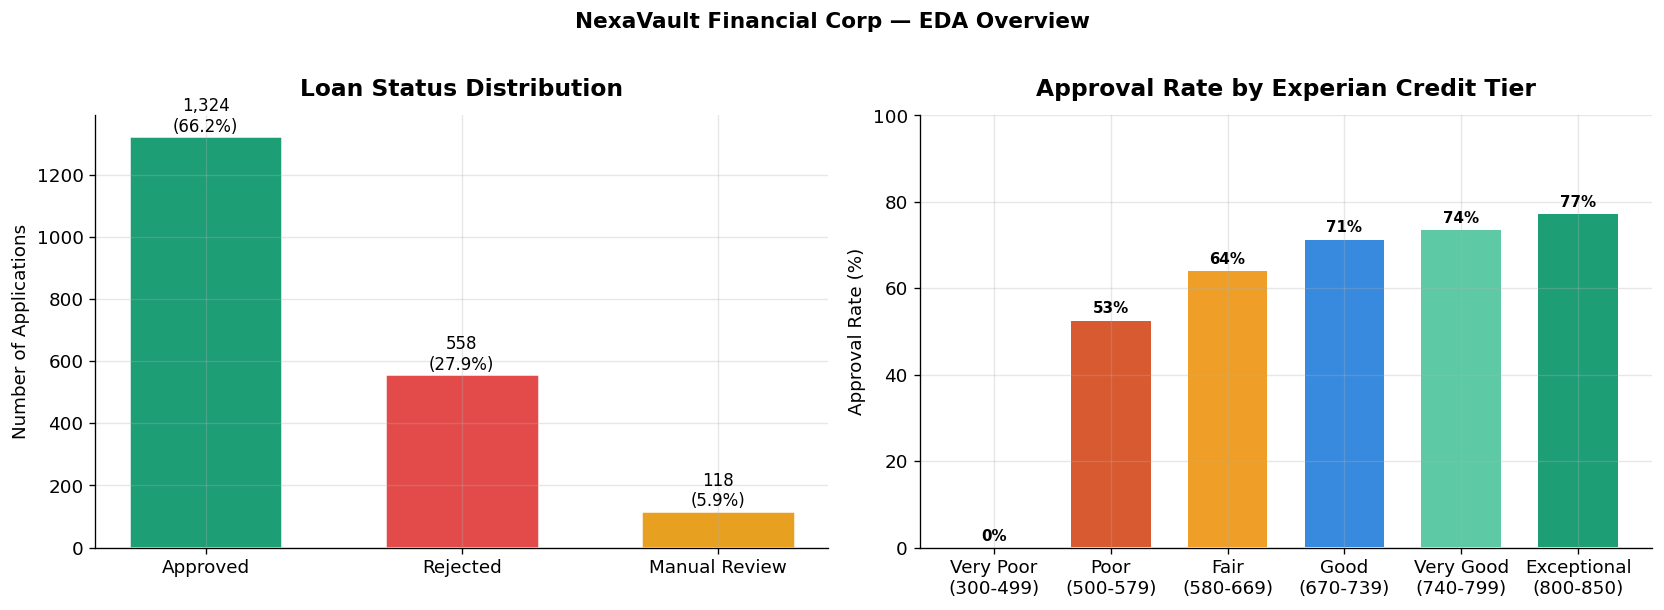

✓ Correct direction: approval rate increases monotonically with credit tier


In [6]:
# ── Plot 1: Target distribution + Credit tier approval rates ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
colors = {"Approved": "#1D9E75", "Manual Review": "#E8A020", "Rejected": "#E24B4A"}
vc = df["Loan_Status"].value_counts()
bars = axes[0].bar(vc.index, vc.values,
                   color=[colors[k] for k in vc.index],
                   edgecolor="white", linewidth=1.5, width=0.6)
axes[0].set_title("Loan Status Distribution", fontsize=14, fontweight="bold", pad=12)
axes[0].set_ylabel("Number of Applications")
for bar, (label, val) in zip(bars, vc.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 15, f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", fontsize=10)

# Credit tier vs approval rate
tier_order = ["Very Poor (300-499)", "Poor (500-579)", "Fair (580-669)",
              "Good (670-739)", "Very Good (740-799)", "Exceptional (800-850)"]
tier_colors = ["#E24B4A","#D85A30","#EF9F27","#378ADD","#5DCAA5","#1D9E75"]
rates = []
for t in tier_order:
    sub = df[df["Credit_Tier"] == t]
    rates.append((sub["Loan_Status"] == "Approved").mean() * 100 if len(sub) > 0 else 0)

short_labels = ["Very Poor\n(300-499)","Poor\n(500-579)","Fair\n(580-669)",
                "Good\n(670-739)","Very Good\n(740-799)","Exceptional\n(800-850)"]
axes[1].bar(short_labels, rates, color=tier_colors, edgecolor="white", linewidth=1.2, width=0.7)
axes[1].set_title("Approval Rate by Experian Credit Tier", fontsize=14, fontweight="bold", pad=12)
axes[1].set_ylabel("Approval Rate (%)")
axes[1].set_ylim(0, 100)
for i, rate in enumerate(rates):
    axes[1].text(i, rate + 1.5, f"{rate:.0f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle(f"{COMPANY} — EDA Overview", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("docs/eda_01_target_credit.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Correct direction: approval rate increases monotonically with credit tier")

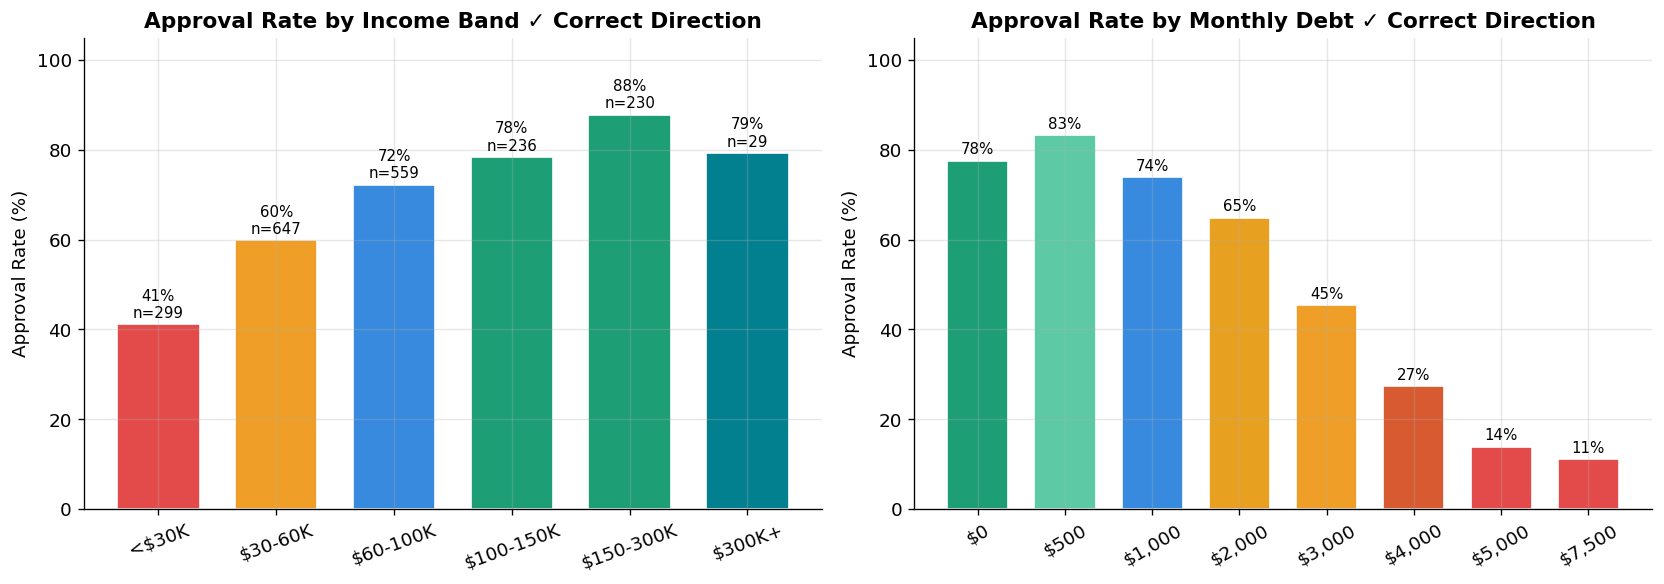

✓ Income: monotonically increasing approval rate
✓ Debt:   monotonically decreasing approval rate


In [7]:
# ── Plot 2: Income vs approval | Debt vs approval ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income bands
bins   = [0, 30000, 60000, 100000, 150000, 300000, 9_999_999]
labels = ["<$30K", "$30-60K", "$60-100K", "$100-150K", "$150-300K", "$300K+"]
df["income_band"] = pd.cut(df["Applicant_Annual_Income"], bins=bins, labels=labels)
inc_rates = []
inc_counts = []
for b in labels:
    sub = df[df["income_band"] == b]
    inc_rates.append((sub["Loan_Status"] == "Approved").mean() * 100 if len(sub) > 0 else 0)
    inc_counts.append(len(sub))

bar_colors_inc = ["#E24B4A","#EF9F27","#378ADD","#1D9E75","#1D9E75","#028090"]
bars = axes[0].bar(labels, inc_rates, color=bar_colors_inc, edgecolor="white", width=0.7)
axes[0].set_title("Approval Rate by Income Band ✓ Correct Direction", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Approval Rate (%)")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=20)
for i, (rate, n) in enumerate(zip(inc_rates, inc_counts)):
    axes[0].text(i, rate + 1.5, f"{rate:.0f}%\nn={n}", ha="center", fontsize=9)

# Debt vs approval
debt_vals = [0, 500, 1000, 2000, 3000, 4000, 5000, 7500]
debt_rates = []
debt_counts = []
for d in debt_vals:
    sub = df[df["Monthly_Debt_Obligations"] == d]
    debt_rates.append((sub["Loan_Status"] == "Approved").mean() * 100 if len(sub) > 0 else 0)
    debt_counts.append(len(sub))

debt_colors = ["#1D9E75","#5DCAA5","#378ADD","#E8A020","#EF9F27","#D85A30","#E24B4A","#E24B4A"]
bars2 = axes[1].bar([f"${d:,}" for d in debt_vals],
                     debt_rates, color=debt_colors, edgecolor="white", width=0.7)
axes[1].set_title("Approval Rate by Monthly Debt ✓ Correct Direction", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Approval Rate (%)")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=30)
for i, (rate, n) in enumerate(zip(debt_rates, debt_counts)):
    if n > 0:
        axes[1].text(i, rate + 1.5, f"{rate:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("docs/eda_02_income_debt.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Income: monotonically increasing approval rate")
print("✓ Debt:   monotonically decreasing approval rate")

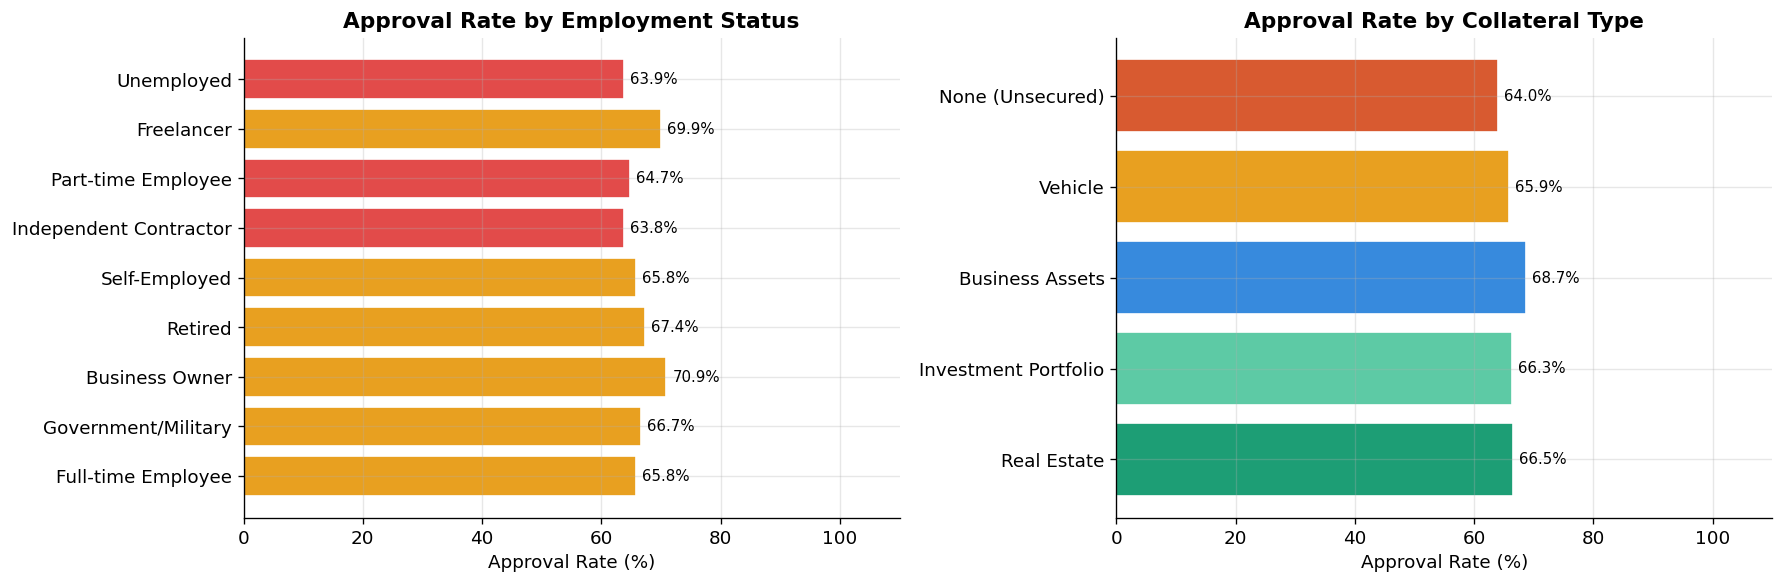

In [8]:
# ── Plot 3: Employment status | Collateral type ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

emp_order = ["Full-time Employee","Government/Military","Business Owner","Retired",
             "Self-Employed","Independent Contractor","Part-time Employee","Freelancer","Unemployed"]
emp_rates = [(df[df["Employment_Status"]==e]["Loan_Status"]=="Approved").mean()*100
             for e in emp_order]
emp_colors = ["#1D9E75" if r >= 80 else "#E8A020" if r >= 65 else "#E24B4A" for r in emp_rates]
axes[0].barh(emp_order, emp_rates, color=emp_colors, edgecolor="white")
axes[0].set_title("Approval Rate by Employment Status", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Approval Rate (%)")
axes[0].set_xlim(0, 110)
for i, rate in enumerate(emp_rates):
    axes[0].text(rate + 1, i, f"{rate:.1f}%", va="center", fontsize=9)

coll_order = ["Real Estate","Investment Portfolio","Business Assets","Vehicle","None (Unsecured)"]
coll_rates = [(df[df["Collateral"]==c]["Loan_Status"]=="Approved").mean()*100
              for c in coll_order]
coll_colors = ["#1D9E75","#5DCAA5","#378ADD","#E8A020","#D85A30"]
axes[1].barh(coll_order, coll_rates, color=coll_colors, edgecolor="white")
axes[1].set_title("Approval Rate by Collateral Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Approval Rate (%)")
axes[1].set_xlim(0, 110)
for i, rate in enumerate(coll_rates):
    axes[1].text(rate + 1, i, f"{rate:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("docs/eda_03_employment_collateral.png", bbox_inches="tight", dpi=150)
plt.show()

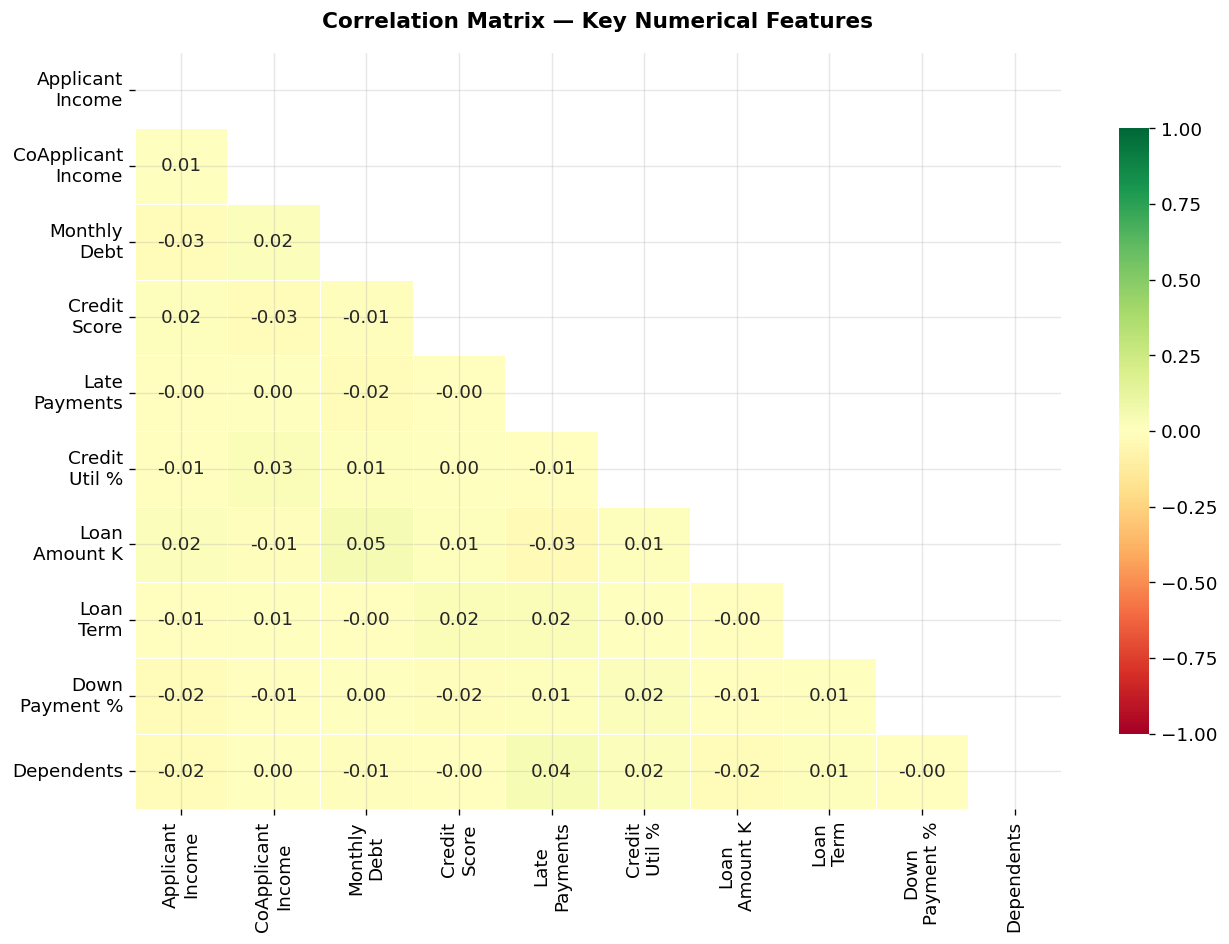


→ Low correlations between input features is good — no severe multicollinearity
→ Income features have slight positive correlation (co-applicant earns more when applicant does)


In [9]:
# ── Plot 4: Correlation heatmap of key numerical features ────────────────
fig, ax = plt.subplots(figsize=(11, 8))

# Compute key numeric correlations
corr_cols = ["Applicant_Annual_Income","CoApplicant_Annual_Income",
             "Monthly_Debt_Obligations","Credit_Score","Late_Payments_2yr",
             "Credit_Utilization_Pct","Loan_Amount_K","Loan_Term_Months",
             "Down_Payment_Pct","Dependents"]
corr_labels = ["Applicant\nIncome","CoApplicant\nIncome","Monthly\nDebt",
               "Credit\nScore","Late\nPayments","Credit\nUtil %",
               "Loan\nAmount K","Loan\nTerm","Down\nPayment %","Dependents"]

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            xticklabels=corr_labels, yticklabels=corr_labels,
            ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Key Numerical Features", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("docs/eda_04_correlation.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n→ Low correlations between input features is good — no severe multicollinearity")
print("→ Income features have slight positive correlation (co-applicant earns more when applicant does)")

---
<a id="4"></a>
## 4. ⚙️ Feature Engineering

Feature engineering transforms raw application fields into signals the model can learn from effectively.

### Two types of transformations:

**1. Ordinal encoding** — for fields with a natural order:
- `Credit_Tier` → 300–825 numeric score (Experian scale)
- `Education` → 0–5 (No education → Doctoral)
- `Employment_Status` → 0–4 risk score (Stable → Unemployed)
- `Bankruptcy_History` → 0–4 severity
- `Collateral` → 0–3 quality score
- `Loan_Type` → 0–2 risk score

**2. Derived financial ratios** — the most important features:

| Feature | Formula | Why It Matters |
|---------|---------|----------------|
| `Income_EMI_Ratio` | Monthly income ÷ EMI | Core affordability signal — can you cover the payment? |
| `DTI_Ratio` | (Debt + EMI) ÷ Monthly income | Standard US lending rule: must be < 43% |
| `Affordability_Score` | Net income ÷ EMI | Residual income after existing obligations |
| `Net_Monthly_Income` | Monthly income − debt | What's left before the new loan |
| `Loan_To_Income` | Loan amount ÷ Annual income | Size of the commitment relative to earnings |
| `Log_Income` | log(1 + total income) | Normalises right-skewed income distribution |

> 💡 The DTI ratio is the standard the CFPB (Consumer Financial Protection Bureau) and FHA use in actual US lending. Below 36% is ideal, 36–43% is acceptable, above 43% is considered risky by most lenders.

In [10]:
# ── Encoding maps ────────────────────────────────────────────────────────
CREDIT_SCORE_MAP = {
    "Exceptional (800-850)": 825, "Very Good (740-799)": 770,
    "Good (670-739)":        705, "Fair (580-669)":       625,
    "Poor (500-579)":        540, "Very Poor (300-499)":  420,
    "No History":            300,
}
EDU_MAP = {
    "No Formal Education": 0, "High School": 1, "Associate Degree": 2,
    "Bachelor's Degree":   3, "Master's Degree": 4, "Doctoral Degree": 5,
}
EMP_RISK_MAP = {
    "Full-time Employee": 0, "Government/Military": 0, "Retired": 1,
    "Business Owner":     1, "Self-Employed": 2, "Independent Contractor": 2,
    "Part-time Employee": 2, "Freelancer": 3, "Unemployed": 4,
}
TENURE_MAP = {
    "<6 months": 0, "6-12 months": 1, "1-2 years": 2,
    "2-5 years": 3, "5-10 years":  4, "10+ years": 5,
}
BANKRUPT_MAP = {
    "None": 0, "Discharged 7+ years ago": 1, "Discharged 2-7 years ago": 2,
    "Discharged under 2 years": 3, "Active/Pending": 4,
}
COLLATERAL_MAP = {
    "Real Estate": 3, "Investment Portfolio": 2, "Business Assets": 2,
    "Vehicle": 1, "None (Unsecured)": 0,
}
LOAN_TYPE_RISK = {
    "Home Purchase": 0, "Home Refinance": 0, "HELOC": 1,
    "Auto Loan": 1,     "Education Loan": 1,  "Debt Consolidation": 2,
    "Business Loan": 2, "Personal Loan": 2,
}

print("✓ Encoding maps defined")
print(f"  Credit tiers:     {len(CREDIT_SCORE_MAP)} categories (300–825 scale)")
print(f"  Education levels: {len(EDU_MAP)} levels (0–5)")
print(f"  Employment types: {len(EMP_RISK_MAP)} types (0=stable, 4=unemployed)")
print(f"  Collateral types: {len(COLLATERAL_MAP)} types (0=unsecured, 3=real estate)")

✓ Encoding maps defined
  Credit tiers:     7 categories (300–825 scale)
  Education levels: 6 levels (0–5)
  Employment types: 9 types (0=stable, 4=unemployed)
  Collateral types: 5 types (0=unsecured, 3=real estate)


In [11]:
# ── Feature engineering function ─────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply all feature transformations to a raw dataframe.
    Works for both training data and single-row inference.
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw application data
        
    Returns
    -------
    pd.DataFrame
        Dataframe with 17 additional engineered features
    """
    d = df.copy()
    
    # Normalize em-dashes in credit tier (handles copy-paste from dashboards)
    if "Credit_Tier" in d.columns:
        d["Credit_Tier"] = (d["Credit_Tier"].astype(str)
                            .str.replace("\u2013", "-", regex=False)
                            .str.replace("\u2014", "-", regex=False))
    
    # ── Ordinal encodings ─────────────────────────────────────────────────
    d["Credit_Score_Num"]  = d["Credit_Tier"].map(CREDIT_SCORE_MAP).fillna(300)
    d["Education_Num"]     = d["Education"].map(EDU_MAP).fillna(2)
    d["Employment_Risk"]   = d["Employment_Status"].map(EMP_RISK_MAP).fillna(2)
    d["Tenure_Num"]        = d["Job_Tenure"].map(TENURE_MAP).fillna(2)
    d["Bankruptcy_Num"]    = d["Bankruptcy_History"].map(BANKRUPT_MAP).fillna(0)
    d["Collateral_Score"]  = d["Collateral"].map(COLLATERAL_MAP).fillna(1)
    d["Loan_Type_Risk"]    = d["Loan_Type"].map(LOAN_TYPE_RISK).fillna(1)
    
    # ── Income aggregation ────────────────────────────────────────────────
    d["Total_Annual_Income"]  = (
        d["Applicant_Annual_Income"]
        + d["CoApplicant_Annual_Income"].fillna(0)
        + d["Other_Income"].fillna(0)
    )
    d["Total_Monthly_Income"] = d["Total_Annual_Income"] / 12.0
    
    # ── Loan cost ─────────────────────────────────────────────────────────
    d["EMI"] = (d["Loan_Amount_K"] * 1000.0) / d["Loan_Term_Months"].replace(0, 360)
    
    # ── Affordability ratios ─────────────────────────────────────────────
    # Income/EMI: monthly income as a multiple of the EMI payment
    #   > 3x = comfortable, 1.5–3x = manageable, < 1.2x = too tight
    d["Income_EMI_Ratio"]  = d["Total_Monthly_Income"] / d["EMI"].replace(0, 1)
    
    # Loan-to-income: how many years of income the loan represents
    #   < 3x = conservative, 3–5x = normal mortgage, > 10x = unserviceable
    d["Loan_To_Income"]    = (d["Loan_Amount_K"] * 1000.0) / d["Total_Annual_Income"].replace(0, 1)
    
    # DTI: total monthly debt burden as % of gross monthly income
    #   < 36% = healthy, 36–43% = borderline, > 43% = risky, > 50% = reject
    monthly_debt          = d["Monthly_Debt_Obligations"].fillna(0)
    d["DTI_Ratio"]        = (monthly_debt + d["EMI"]) / d["Total_Monthly_Income"].replace(0, 1)
    
    # Net income and affordability
    d["Net_Monthly_Income"]  = d["Total_Monthly_Income"] - monthly_debt
    d["Affordability_Score"] = d["Net_Monthly_Income"] / d["EMI"].replace(0, 1)
    
    # ── Log transforms (reduce right skew) ───────────────────────────────
    d["Log_Income"] = np.log1p(d["Total_Annual_Income"])
    d["Log_Loan"]   = np.log1p(d["Loan_Amount_K"])
    
    return d

# Apply to training data
df = engineer_features(df)
print(f"✓ Feature engineering complete")
print(f"  Total features: {df.shape[1]} (was 25, added {df.shape[1]-25} engineered features)")
print(f"\n  New features created:")
new_feats = ["Credit_Score_Num","Education_Num","Employment_Risk","Tenure_Num",
             "Bankruptcy_Num","Collateral_Score","Loan_Type_Risk","Total_Annual_Income",
             "Total_Monthly_Income","EMI","Income_EMI_Ratio","Loan_To_Income",
             "DTI_Ratio","Net_Monthly_Income","Affordability_Score","Log_Income","Log_Loan"]
for f in new_feats:
    print(f"  ✓ {f}")

✓ Feature engineering complete
  Total features: 43 (was 25, added 18 engineered features)

  New features created:
  ✓ Credit_Score_Num
  ✓ Education_Num
  ✓ Employment_Risk
  ✓ Tenure_Num
  ✓ Bankruptcy_Num
  ✓ Collateral_Score
  ✓ Loan_Type_Risk
  ✓ Total_Annual_Income
  ✓ Total_Monthly_Income
  ✓ EMI
  ✓ Income_EMI_Ratio
  ✓ Loan_To_Income
  ✓ DTI_Ratio
  ✓ Net_Monthly_Income
  ✓ Affordability_Score
  ✓ Log_Income
  ✓ Log_Loan


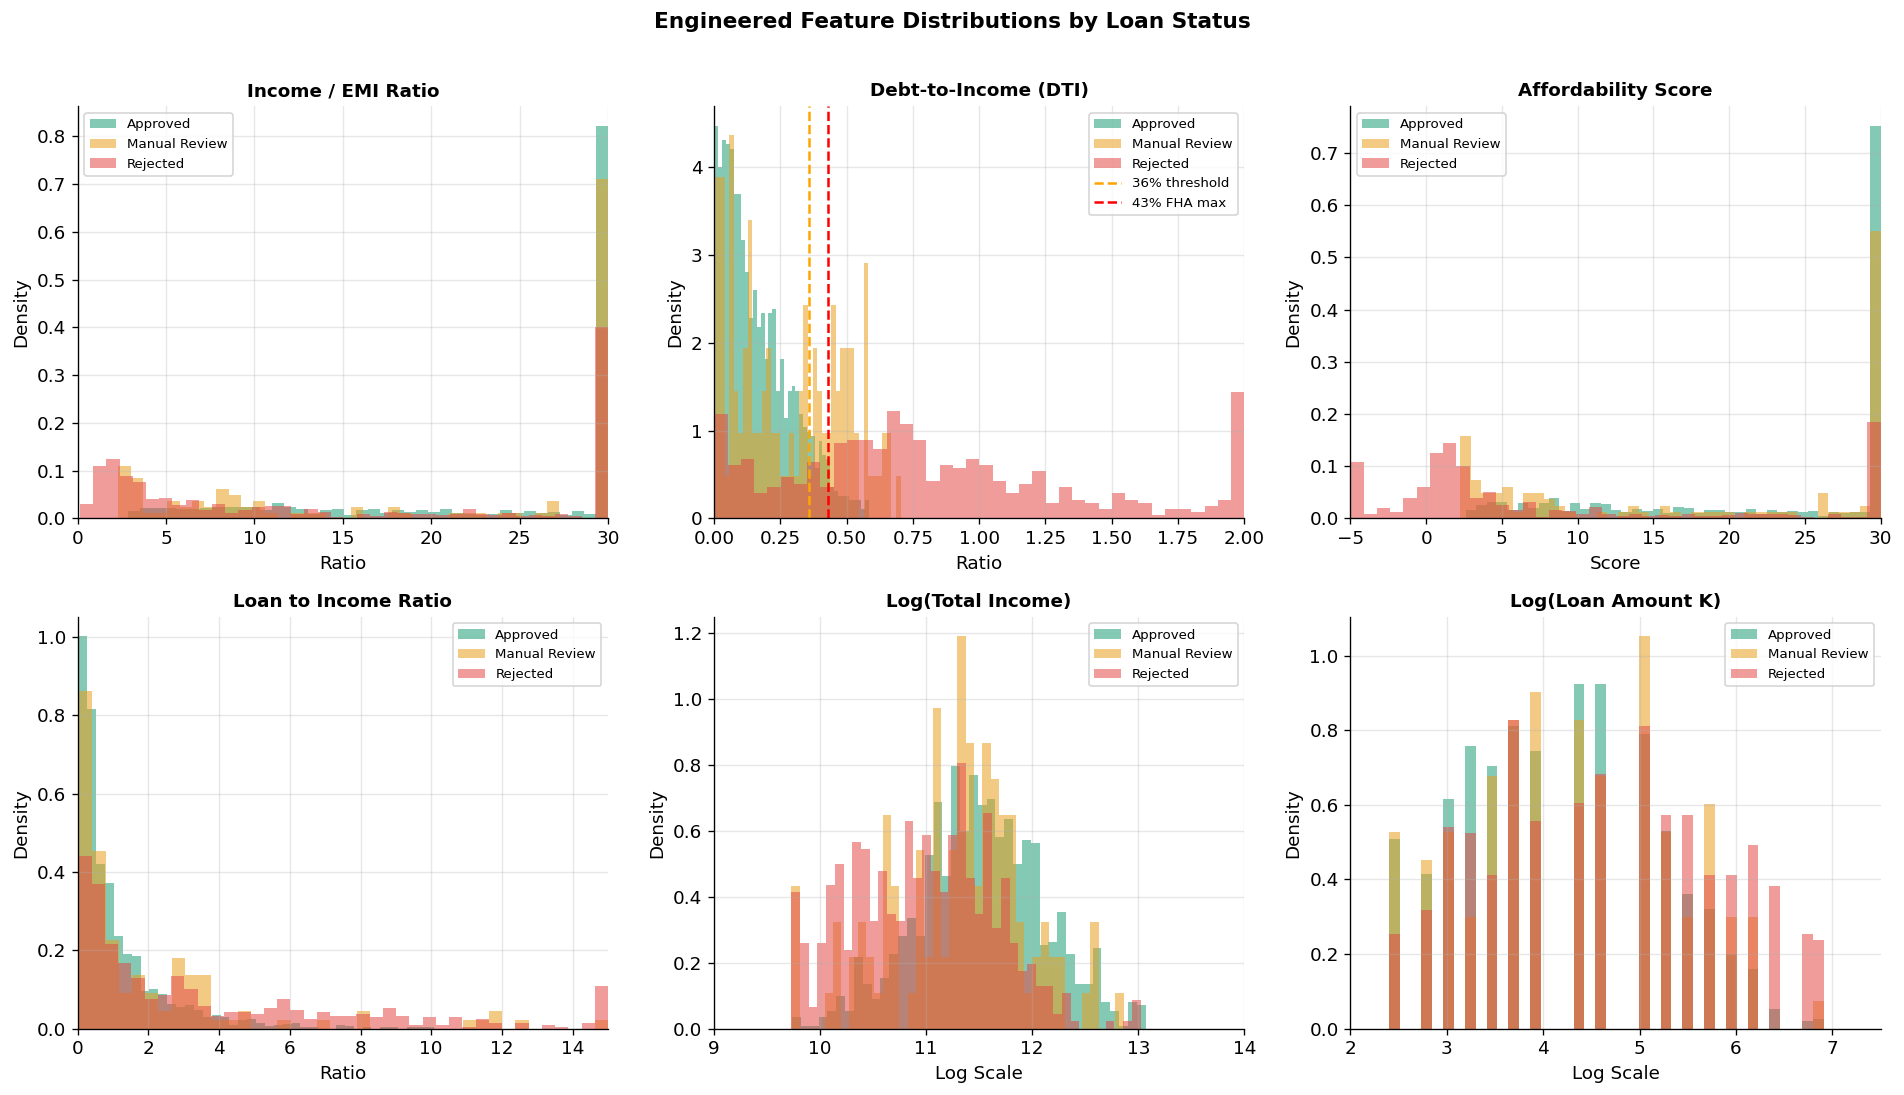


→ Income/EMI ratio: clear separation — approved loans have higher ratio
→ DTI ratio: approved loans cluster below the 0.43 threshold


In [12]:
# ── Visualize the key derived features ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
palette = {"Approved":"#1D9E75","Manual Review":"#E8A020","Rejected":"#E24B4A"}

plot_features = [
    ("Income_EMI_Ratio",    "Income / EMI Ratio",    "Ratio",    (0, 30)),
    ("DTI_Ratio",           "Debt-to-Income (DTI)",  "Ratio",    (0, 2)),
    ("Affordability_Score", "Affordability Score",   "Score",    (-5, 30)),
    ("Loan_To_Income",      "Loan to Income Ratio",  "Ratio",    (0, 15)),
    ("Log_Income",          "Log(Total Income)",     "Log Scale",(9, 14)),
    ("Log_Loan",            "Log(Loan Amount K)",    "Log Scale",(2, 7.5)),
]

for ax, (feat, title, xlabel, xlim) in zip(axes.flat, plot_features):
    for status, color in palette.items():
        subset = df[df["Loan_Status"] == status][feat].clip(*xlim)
        ax.hist(subset, bins=40, alpha=0.55, color=color, label=status, density=True)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_xlim(xlim)
    ax.legend(fontsize=8)

# Add reference lines for DTI
axes[0, 1].axvline(0.36, color="orange", linestyle="--", linewidth=1.5, label="36% threshold")
axes[0, 1].axvline(0.43, color="red",    linestyle="--", linewidth=1.5, label="43% FHA max")
axes[0, 1].legend(fontsize=8)

plt.suptitle("Engineered Feature Distributions by Loan Status",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("docs/eda_05_engineered_features.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n→ Income/EMI ratio: clear separation — approved loans have higher ratio")
print("→ DTI ratio: approved loans cluster below the 0.43 threshold")

---
<a id="5"></a>
## 5. 🔄 Data Preprocessing Pipeline

We use sklearn's `ColumnTransformer` to apply different transformations to numerical and categorical features — all in a reproducible, leak-proof pipeline.

### Why a Pipeline?
- **No data leakage:** scaling statistics are fitted on training data only, then applied to test data
- **Reproducibility:** same transformations applied consistently to training, validation, and inference
- **Deployment ready:** the entire pipeline (preprocessor + model) is saved as a single object

### Feature groups

| Group | Features | Transformation |
|-------|---------|----------------|
| **Numerical** (22 features) | Income, EMI, ratios, ordinal encodings | Median imputation → StandardScaler |
| **Categorical** (5 features) | Gender, Marital Status, Loan Purpose, Property Area, Industry | Mode imputation → OneHotEncoder |
| **Dropped** | Loan_ID, Credit_Score (raw), Loan_Type, Collateral, Education, Employment_Status, Job_Tenure, Bankruptcy_History | Already encoded numerically or non-informative |

In [13]:
# ── Define feature groups ─────────────────────────────────────────────────
NUM_FEATURES = [
    # Credit & financial history
    "Credit_Score_Num", "Bankruptcy_Num", "Late_Payments_2yr",
    "Credit_Utilization_Pct",
    # Employment & personal
    "Education_Num", "Employment_Risk", "Tenure_Num", "Dependents",
    # Income
    "Total_Annual_Income", "Log_Income",
    # Loan characteristics  
    "Loan_Amount_K", "Loan_Term_Months", "Down_Payment_Pct",
    "Loan_Type_Risk", "Collateral_Score", "Log_Loan",
    # Key derived ratios
    "EMI", "Income_EMI_Ratio", "Loan_To_Income",
    "DTI_Ratio", "Net_Monthly_Income", "Affordability_Score",
]

CAT_FEATURES = [
    "Gender", "Marital_Status", "Loan_Purpose",
    "Property_Area", "Industry",
]

# Columns to drop before training
DROP_COLS = [
    "Loan_ID",           # identifier — no predictive value
    "Loan_Status",       # target variable
    "Target",            # encoded target
    "Credit_Tier",       # replaced by Credit_Score_Num
    "Credit_Score",      # redundant with Credit_Score_Num
    "Employment_Status", # replaced by Employment_Risk
    "Job_Tenure",        # replaced by Tenure_Num
    "Education",         # replaced by Education_Num
    "Bankruptcy_History",# replaced by Bankruptcy_Num
    "Loan_Type",         # replaced by Loan_Type_Risk
    "Collateral",        # replaced by Collateral_Score
    "income_band",       # temporary EDA column
]

print(f"✓ Feature groups defined:")
print(f"  Numerical features:    {len(NUM_FEATURES)}")
print(f"  Categorical features:  {len(CAT_FEATURES)}")
print(f"  Dropped columns:       {len(DROP_COLS)}")
print(f"  Total model features:  {len(NUM_FEATURES) + len(CAT_FEATURES)} (before OHE expansion)")

✓ Feature groups defined:
  Numerical features:    22
  Categorical features:  5
  Dropped columns:       12
  Total model features:  27 (before OHE expansion)


In [14]:
# ── Build preprocessing pipeline ─────────────────────────────────────────
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # robust to outliers
    ("scaler",  StandardScaler()),                    # mean=0, std=1
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",   # unseen categories → all zeros
        sparse_output=False        # return dense array
    )),
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline,   NUM_FEATURES),
    ("cat", categorical_pipeline, CAT_FEATURES),
])

print("✓ Preprocessing pipeline built")
print("  Numerical:   Median imputation → StandardScaler")
print("  Categorical: Mode imputation → OneHotEncoder (handle_unknown=ignore)")

✓ Preprocessing pipeline built
  Numerical:   Median imputation → StandardScaler
  Categorical: Mode imputation → OneHotEncoder (handle_unknown=ignore)


In [15]:
# ── Prepare target and train/test split ──────────────────────────────────
# Binary target: Approved=1, anything else=0
# (Manual Review cases train the model to be cautious, not to approve blindly)
df["Target"] = (df["Loan_Status"] == "Approved").astype(int)

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df["Target"]

# Stratified split preserves the class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 80/20 split
    stratify=y,          # preserve class balance
    random_state=42
)

print(f"✓ Train/test split complete")
print(f"  Training:   {len(X_train):,} records ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Test:       {len(X_test):,}  records ({len(X_test)/len(df)*100:.0f}%)")
print(f"  Approval rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")
print(f"  ✓ Class balance preserved across split (stratify=y)")

✓ Train/test split complete
  Training:   1,600 records (80%)
  Test:       400  records (20%)
  Approval rate — Train: 66.2% | Test: 66.2%
  ✓ Class balance preserved across split (stratify=y)


---
<a id="6"></a>
## 6. 🤖 Model Training

We train and compare four candidate models using **5-fold stratified cross-validation**.

### Why these four models?

| Model | Strength | Weakness | When to prefer |
|-------|---------|---------|----------------|
| **Logistic Regression** | Fast, interpretable, good baseline | Linear boundaries only | When explainability is critical |
| **Random Forest** | Robust to outliers, handles non-linearity | Slow to train, large files | When you need feature importance |
| **Gradient Boosting** | Best accuracy, handles complex patterns | Slower, more hyperparameters | Production — highest accuracy |
| **SVM (RBF)** | Excellent on medium datasets | Slow on large datasets, no feature importance | When dataset is < 10K rows |

### Cross-validation strategy
We use **stratified 5-fold CV** — each fold maintains the same class ratio as the full dataset. This gives a robust estimate of generalization performance.

**Primary metric: ROC-AUC** (not accuracy)
- Accuracy is misleading with imbalanced classes
- ROC-AUC measures the model's ability to rank approved vs rejected applicants
- 0.5 = random, 1.0 = perfect

In [16]:
# ── Define candidate models ───────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8,
        min_samples_split=10, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", probability=True,
        C=2.0, gamma="scale", random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✓ Models configured:")
for name in models:
    print(f"  · {name}")
print()
print("Training strategy: 5-fold stratified cross-validation")
print("Primary metric:    ROC-AUC")
print("Secondary metrics: F1, Precision, Recall, Accuracy")

✓ Models configured:
  · Logistic Regression
  · Random Forest
  · Gradient Boosting
  · SVM (RBF)

Training strategy: 5-fold stratified cross-validation
Primary metric:    ROC-AUC
Secondary metrics: F1, Precision, Recall, Accuracy


In [17]:
# ── Train all models and collect results ─────────────────────────────────
results = {}

print("=" * 65)
print("  5-Fold Stratified Cross-Validation Results")
print("=" * 65)

for name, clf in models.items():
    # Build full pipeline: preprocessor + classifier
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   clf),
    ])
    
    # Cross-validate (trains and scores on 5 different folds)
    cv_scores = cross_val_score(pipe, X_train, y_train,
                                cv=cv, scoring="roc_auc", n_jobs=-1)
    
    # Fit final model on full training set
    pipe.fit(X_train, y_train)
    
    # Evaluate on held-out test set
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "pipeline":  pipe,
        "cv_mean":   cv_scores.mean(),
        "cv_std":    cv_scores.std(),
        "auc":       roc_auc_score(y_test, y_prob),
        "f1":        f1_score(y_test, y_pred),
        "acc":       accuracy_score(y_test, y_pred),
        "prec":      precision_score(y_test, y_pred),
        "rec":       recall_score(y_test, y_pred),
        "y_pred":    y_pred,
        "y_prob":    y_prob,
    }
    
    r = results[name]
    print(f"  {name:<22}  CV: {r['cv_mean']:.4f} ±{r['cv_std']:.4f}  │  Test AUC: {r['auc']:.4f}  F1: {r['f1']:.4f}")

print()
best_name = max(results, key=lambda n: results[n]["auc"])
print(f"  ★ Best model: {best_name} (Test AUC = {results[best_name]['auc']:.4f})")

  5-Fold Stratified Cross-Validation Results
  Logistic Regression     CV: 0.9823 ±0.0045  │  Test AUC: 0.9903  F1: 0.9642
  Random Forest           CV: 0.9786 ±0.0050  │  Test AUC: 0.9894  F1: 0.9610
  Gradient Boosting       CV: 0.9945 ±0.0021  │  Test AUC: 0.9977  F1: 0.9812
  SVM (RBF)               CV: 0.9852 ±0.0052  │  Test AUC: 0.9890  F1: 0.9663

  ★ Best model: Gradient Boosting (Test AUC = 0.9977)


---
<a id="7"></a>
## 7. 📊 Model Evaluation

Thorough evaluation looks beyond a single number. We examine:
- **ROC curves** — overall discriminative ability across all thresholds
- **Precision-Recall curves** — performance on the positive class (approvals)
- **Confusion matrix** — breakdown of correct vs incorrect decisions
- **Classification report** — precision, recall, F1 per class

### Business meaning of metrics

| Metric | What it measures | Business impact if low |
|--------|-----------------|----------------------|
| **Precision** | Of all approved, how many truly qualify? | Too many bad loans approved → financial loss |
| **Recall** | Of all qualified applicants, how many approved? | Too many good customers rejected → lost revenue |
| **F1** | Balance of precision and recall | Overall decision quality |
| **ROC-AUC** | Ranking quality across all thresholds | Model's fundamental discriminative ability |

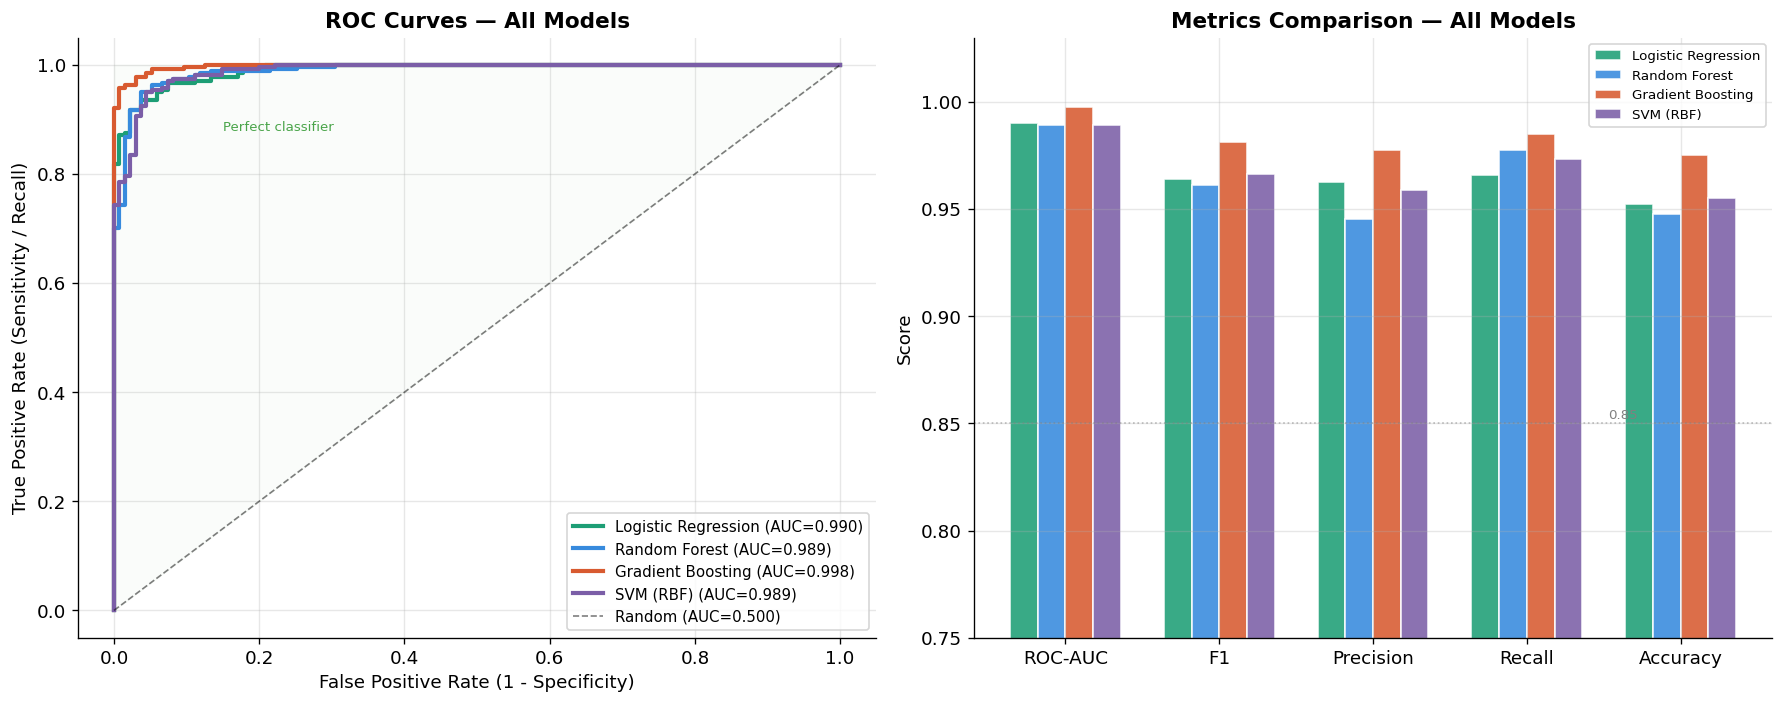

In [18]:
# ── ROC curves for all models ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_colors = ["#1D9E75","#378ADD","#D85A30","#7B5EA7"]
model_names = list(results.keys())

# ROC curves
for (name, r), color in zip(results.items(), plot_colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})",
                 color=color, linewidth=2.5)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC=0.500)")
axes[0].fill_between([0,1],[0,1],[1,1], alpha=0.02, color="green")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[0].set_title("ROC Curves — All Models", fontweight="bold", fontsize=13)
axes[0].legend(loc="lower right", fontsize=9)
axes[0].annotate("Perfect classifier", xy=(0,1), xytext=(0.15, 0.88),
                 fontsize=8, color="green", alpha=0.7)

# Metrics comparison bar chart
metrics = ["auc", "f1", "prec", "rec", "acc"]
labels  = ["ROC-AUC", "F1", "Precision", "Recall", "Accuracy"]
x = np.arange(len(metrics))
width = 0.18

for i, (name, color) in enumerate(zip(model_names, plot_colors)):
    vals = [results[name][m] for m in metrics]
    axes[1].bar(x + i * width, vals, width, label=name, color=color, alpha=0.88, edgecolor="white")

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0.75, 1.03)
axes[1].set_ylabel("Score")
axes[1].set_title("Metrics Comparison — All Models", fontweight="bold", fontsize=13)
axes[1].legend(fontsize=8)

# Add reference line at 0.85
axes[1].axhline(0.85, color="gray", linestyle=":", linewidth=1, alpha=0.5)
axes[1].text(3.8, 0.852, "0.85", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("docs/model_01_roc_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

In [19]:
# ── Detailed evaluation of best model ────────────────────────────────────
best_model = results[best_name]["pipeline"]
best_res   = results[best_name]

print(f"{'='*60}")
print(f"  Best Model: {best_name}")
print(f"{'='*60}")
print()
print(f"  ROC-AUC:   {best_res['auc']*100:.2f}%")
print(f"  Accuracy:  {best_res['acc']*100:.2f}%")
print(f"  Precision: {best_res['prec']*100:.2f}%  (of approved, % truly qualified)")
print(f"  Recall:    {best_res['rec']*100:.2f}%   (of qualified, % correctly approved)")
print(f"  F1 Score:  {best_res['f1']*100:.2f}%")
print()
print("  Full Classification Report:")
print(classification_report(y_test, best_res["y_pred"],
                            target_names=["Rejected / Review", "Approved"],
                            digits=4))

  Best Model: Gradient Boosting

  ROC-AUC:   99.77%
  Accuracy:  97.50%
  Precision: 97.75%  (of approved, % truly qualified)
  Recall:    98.49%   (of qualified, % correctly approved)
  F1 Score:  98.12%

  Full Classification Report:
                   precision    recall  f1-score   support

Rejected / Review     0.9699    0.9556    0.9627       135
         Approved     0.9775    0.9849    0.9812       265

         accuracy                         0.9750       400
        macro avg     0.9737    0.9702    0.9719       400
     weighted avg     0.9750    0.9750    0.9750       400



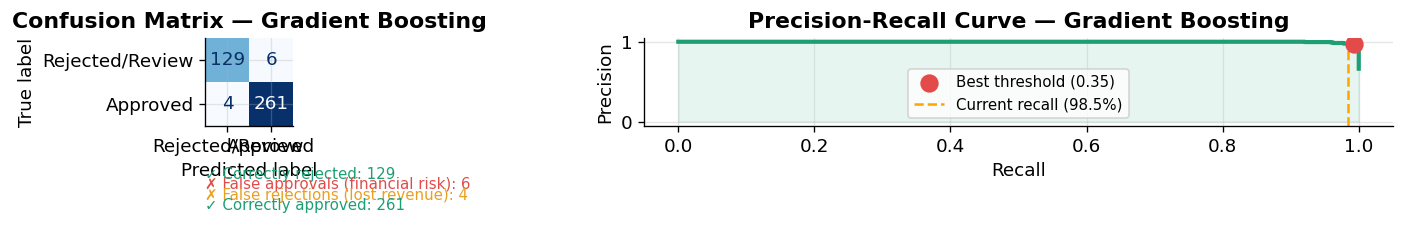


  Optimal classification threshold: 0.345
  Current threshold used:           0.650 (Approved)
  Business rule: ≥ 0.65 = Approved, 0.45–0.65 = Manual Review, < 0.45 = Rejected


In [20]:
# ── Confusion matrix ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix — counts
cm = confusion_matrix(y_test, best_res["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Rejected/Review","Approved"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix — {best_name}", fontweight="bold")

# Annotate business impact
tn, fp, fn, tp = cm.ravel()
axes[0].text(0, -0.6, f"✓ Correctly rejected: {tn}", transform=axes[0].transAxes,
             fontsize=9, color="#1D9E75")
axes[0].text(0, -0.72, f"✗ False approvals (financial risk): {fp}", transform=axes[0].transAxes,
             fontsize=9, color="#E24B4A")
axes[0].text(0, -0.84, f"✗ False rejections (lost revenue): {fn}", transform=axes[0].transAxes,
             fontsize=9, color="#E8A020")
axes[0].text(0, -0.96, f"✓ Correctly approved: {tp}", transform=axes[0].transAxes,
             fontsize=9, color="#1D9E75")

# Precision-Recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_res["y_prob"])
f1_scores_pr = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-9)
best_thresh_idx = np.argmax(f1_scores_pr)
best_thresh = thresholds[best_thresh_idx] if best_thresh_idx < len(thresholds) else 0.65

axes[1].plot(recall_vals, precision_vals, color="#1D9E75", linewidth=2.5)
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color="#1D9E75")
axes[1].scatter(recall_vals[best_thresh_idx], precision_vals[best_thresh_idx],
                s=100, color="#E24B4A", zorder=5, label=f"Best threshold ({best_thresh:.2f})")
axes[1].axvline(best_res["rec"], color="orange", linestyle="--", linewidth=1.5,
                label=f"Current recall ({best_res['rec']*100:.1f}%)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve — {best_name}", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("docs/model_02_confusion_pr.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\n  Optimal classification threshold: {best_thresh:.3f}")
print(f"  Current threshold used:           0.650 (Approved)")
print(f"  Business rule: ≥ 0.65 = Approved, 0.45–0.65 = Manual Review, < 0.45 = Rejected")

---
<a id="8"></a>
## 8. 🔬 Feature Importance Analysis

Understanding *which* features drive decisions is critical for:
- **Regulatory compliance** — explaining decisions to applicants (ECOA, FCRA)
- **Model debugging** — catching unintended signal leakage
- **Business insight** — confirming the model learned real lending logic

### Note on tree-based importance
Gradient Boosting provides native feature importances based on how much each feature reduces impurity across all trees. For linear models (LR) we use coefficient magnitudes. For SVMs, we would use permutation importance (shown in Enhancements section).

In [21]:
# ── Extract feature importances ──────────────────────────────────────────
clf = best_model.named_steps["classifier"]
pre = best_model.named_steps["preprocessor"]

# Recover feature names after OHE
num_names = NUM_FEATURES
ohe       = pre.transformers_[1][1].named_steps["encoder"]
cat_names = list(ohe.get_feature_names_out(CAT_FEATURES))
all_names = num_names + cat_names

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    importance_type = "Gini Impurity Reduction (Tree-based)"
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
    importance_type = "|Coefficient| (Linear)"
else:
    print("Feature importance not available for this model type.")
    importances = None

if importances is not None:
    # Sort by importance
    indices = np.argsort(importances)[::-1]
    top_n   = 20
    
    print(f"Feature Importance Type: {importance_type}")
    print(f"\nTop {top_n} features:")
    print("-" * 55)
    for rank, i in enumerate(indices[:top_n], 1):
        bar = "█" * int(importances[i] * 500)
        print(f"  {rank:2}. {all_names[i]:<32} {importances[i]:.4f}  {bar}")

Feature Importance Type: Gini Impurity Reduction (Tree-based)

Top 20 features:
-------------------------------------------------------
   1. DTI_Ratio                        0.5326  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. Credit_Score_Num                 0.1759  ███████████████████████████████████████████████████████████████████████████████████████
   3. Late_Payments_2yr                0.1194  ███████████████████████████████████████████████████████████
   4. Bankruptcy_Num                   0.0760  █████████████████████████████████████
   5. Affordability_Score              0.0201  ██████████
   6. Income_EMI_Ratio                 0.0147  ███████
   7. Net_Monthly_Income               0.0129  ██████
   8. Loan_To_Income                   0.0091  ████
   9

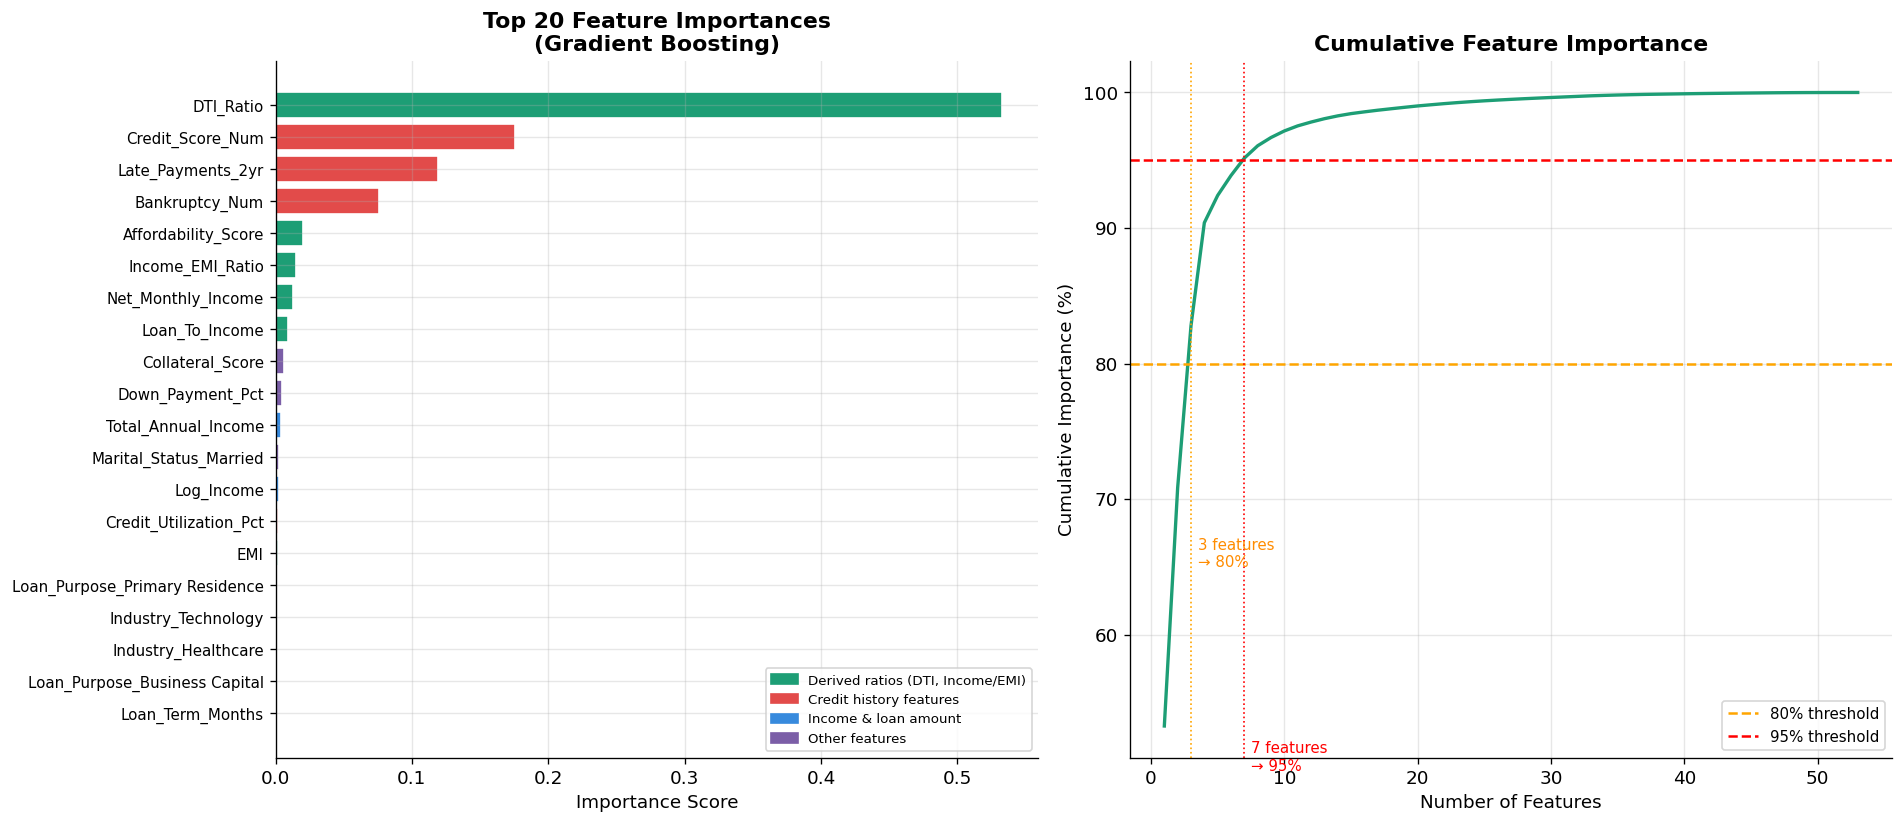

In [22]:
# ── Feature importance visualization ─────────────────────────────────────
if importances is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Top 20 features
    top_n   = 20
    idx     = np.argsort(importances)[::-1][:top_n]
    top_imp = importances[idx]
    top_nms = [all_names[i] for i in idx]
    
    # Color by feature type
    colors = []
    for name in top_nms:
        if name in ["Income_EMI_Ratio","DTI_Ratio","Affordability_Score",
                    "Net_Monthly_Income","Loan_To_Income","EMI"]:
            colors.append("#1D9E75")  # derived ratios
        elif name in ["Credit_Score_Num","Bankruptcy_Num","Late_Payments_2yr","Credit_Utilization_Pct"]:
            colors.append("#E24B4A")  # credit features
        elif name in ["Total_Annual_Income","Log_Income","Loan_Amount_K","Log_Loan"]:
            colors.append("#378ADD")  # income/loan features
        else:
            colors.append("#7B5EA7")  # other
    
    bars = axes[0].barh(range(top_n), top_imp[::-1], color=colors[::-1], edgecolor="white")
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels(top_nms[::-1], fontsize=9)
    axes[0].set_xlabel("Importance Score")
    axes[0].set_title(f"Top {top_n} Feature Importances\n({best_name})", fontweight="bold")
    
    # Legend
    patches = [
        mpatches.Patch(color="#1D9E75", label="Derived ratios (DTI, Income/EMI)"),
        mpatches.Patch(color="#E24B4A", label="Credit history features"),
        mpatches.Patch(color="#378ADD", label="Income & loan amount"),
        mpatches.Patch(color="#7B5EA7", label="Other features"),
    ]
    axes[0].legend(handles=patches, fontsize=8, loc="lower right")
    
    # Cumulative importance
    cum_imp = np.cumsum(np.sort(importances)[::-1])
    axes[1].plot(range(1, len(cum_imp)+1), cum_imp * 100, color="#1D9E75", linewidth=2)
    axes[1].axhline(80, color="orange", linestyle="--", linewidth=1.5, label="80% threshold")
    axes[1].axhline(95, color="red",    linestyle="--", linewidth=1.5, label="95% threshold")
    n_80 = np.argmax(cum_imp >= 0.80) + 1
    n_95 = np.argmax(cum_imp >= 0.95) + 1
    axes[1].axvline(n_80, color="orange", linestyle=":", linewidth=1)
    axes[1].axvline(n_95, color="red",    linestyle=":", linewidth=1)
    axes[1].text(n_80+0.5, 65, f"{n_80} features\n→ 80%", fontsize=9, color="darkorange")
    axes[1].text(n_95+0.5, 50, f"{n_95} features\n→ 95%", fontsize=9, color="red")
    axes[1].set_xlabel("Number of Features")
    axes[1].set_ylabel("Cumulative Importance (%)")
    axes[1].set_title("Cumulative Feature Importance", fontweight="bold")
    axes[1].legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig("docs/model_03_feature_importance.png", bbox_inches="tight", dpi=150)
    plt.show()

---
<a id="9"></a>
## 9. 🛡️ Hard Underwriting Rules

In production, the ML model is **preceded by 9 hard rule-based gates**. This is how real banks work — machine learning handles nuanced cases, but absolute rules protect against financially impossible approvals.

### Why rules AND ML?

| Approach | Weakness |
|---------|---------|
| ML only | Can approve physically impossible loans (e.g., DTI > 100%) if not seen in training |
| Rules only | Cannot learn subtle patterns from data |
| **Rules + ML** | ✅ Best of both — gates prevent impossible cases, ML handles the rest |

### The 9 gates

| # | Rule | Threshold | Basis |
|---|------|-----------|-------|
| 1 | DTI > 50% | Hard reject | FHA max is 43%; 50% is absolute ceiling |
| 2 | Income/EMI < 1.20× | Hard reject | Can't cover the payment |
| 3 | Residual income < $200/mo | Hard reject | Nothing left to live on |
| 4 | Active/pending bankruptcy | Hard reject | Legal protection period |
| 5 | 4+ late payments (2 yrs) | Hard reject | Established pattern of default |
| 6 | Credit score ≤ 499 | Hard reject | Below minimum for any product |
| 7 | Loan > 10× annual income | Hard reject | No lender accepts this |
| 8 | Credit 500–579 + down < 10% + loan ≥ $100K | Manual review cap | FHA minimum 10% down for < 580 |
| 9 | DTI 43–50% | Manual review cap | Borderline — needs human judgment |

In [23]:
# ── Implement and test the hard gates ─────────────────────────────────────
def hard_gates(applicant: dict) -> tuple:
    """
    Apply 9 hard underwriting rules before the ML model.
    
    Returns
    -------
    rejections : list of str
        Hard rejection reasons (empty = passes all gates)
    reviews : list of str  
        Soft flags that cap probability into Manual Review zone
    """
    rejections, reviews = [], []
    
    app_inc  = float(applicant.get("Applicant_Annual_Income", 0))
    co_inc   = float(applicant.get("CoApplicant_Annual_Income", 0) or 0)
    other    = float(applicant.get("Other_Income", 0) or 0)
    mdebt    = float(applicant.get("Monthly_Debt_Obligations", 0) or 0)
    loan_k   = float(applicant.get("Loan_Amount_K", 0))
    term     = float(applicant.get("Loan_Term_Months", 360) or 360)
    late     = int(applicant.get("Late_Payments_2yr", 0) or 0)
    bankrupt = str(applicant.get("Bankruptcy_History", "None"))
    ctier    = str(applicant.get("Credit_Tier", "")).replace("\u2013", "-")
    down_pct = float(applicant.get("Down_Payment_Pct", 0) or 0)
    
    total_ann = app_inc + co_inc + other
    total_mo  = total_ann / 12.0
    emi       = (loan_k * 1000.0) / max(term, 1)
    dti       = (mdebt + emi) / max(total_mo, 1)
    inc_emi   = total_mo / max(emi, 1)
    net_resid = total_mo - mdebt - emi
    cscore    = CREDIT_SCORE_MAP.get(ctier, 300)
    lti       = (loan_k * 1000) / max(total_ann, 1)
    
    # Hard rejects
    if dti > 0.50:
        rejections.append(f"Gate 1: DTI {dti*100:.1f}% exceeds 50% maximum")
    if inc_emi < 1.20:
        rejections.append(f"Gate 2: Income/EMI {inc_emi:.2f}x below 1.20x minimum")
    if net_resid < 200:
        rejections.append(f"Gate 3: Residual income ${net_resid:,.0f}/mo below $200 minimum")
    if bankrupt == "Active/Pending":
        rejections.append("Gate 4: Active/pending bankruptcy on file")
    if late >= 4:
        rejections.append(f"Gate 5: {late} late payments in 2 years (max 3 allowed)")
    if cscore <= 499:
        rejections.append(f"Gate 6: Credit score {cscore} (Very Poor) below 500 minimum")
    if lti > 10.0:
        rejections.append(f"Gate 7: Loan {lti:.1f}x annual income exceeds 10x maximum")
    
    # Soft caps → Manual Review
    if 500 <= cscore <= 579 and loan_k >= 100 and down_pct < 10:
        reviews.append(f"Gate 8: Credit {cscore} with <10% down on ${loan_k}K loan requires FHA minimum 10% down")
    if 0.43 < dti <= 0.50 and not rejections:
        reviews.append(f"Gate 9: DTI {dti*100:.1f}% exceeds 43% preferred threshold — manual review required")
    
    return rejections, reviews


# ── Test the gates ────────────────────────────────────────────────────────
print("=== GATE VERIFICATION TESTS ===\n")

test_cases = [
    ("✅ APPROVE: $380K income, Exceptional credit, $500K home",
     {"Applicant_Annual_Income":350000,"CoApplicant_Annual_Income":30000,
      "Monthly_Debt_Obligations":500,"Loan_Amount_K":500,"Loan_Term_Months":360,
      "Credit_Tier":"Exceptional (800-850)","Late_Payments_2yr":0,
      "Bankruptcy_History":"None","Down_Payment_Pct":20}),
    
    ("❌ REJECT: $55K income, $1500 debt, $500K loan (DTI > 50%)",
     {"Applicant_Annual_Income":25000,"CoApplicant_Annual_Income":30000,
      "Monthly_Debt_Obligations":1500,"Loan_Amount_K":500,"Loan_Term_Months":360,
      "Credit_Tier":"Exceptional (800-850)","Late_Payments_2yr":0,
      "Bankruptcy_History":"None","Down_Payment_Pct":5}),
    
    ("❌ REJECT: Very Poor credit (420) — Gate 6",
     {"Applicant_Annual_Income":100000,"CoApplicant_Annual_Income":0,
      "Monthly_Debt_Obligations":500,"Loan_Amount_K":100,"Loan_Term_Months":180,
      "Credit_Tier":"Very Poor (300-499)","Late_Payments_2yr":0,
      "Bankruptcy_History":"None","Down_Payment_Pct":20}),
    
    ("⏸ REVIEW: Poor credit + <10% down + $200K loan — Gate 8",
     {"Applicant_Annual_Income":100000,"CoApplicant_Annual_Income":0,
      "Monthly_Debt_Obligations":500,"Loan_Amount_K":200,"Loan_Term_Months":180,
      "Credit_Tier":"Poor (500-579)","Late_Payments_2yr":0,
      "Bankruptcy_History":"None","Down_Payment_Pct":5}),
    
    ("❌ REJECT: Active bankruptcy — Gate 4",
     {"Applicant_Annual_Income":200000,"CoApplicant_Annual_Income":50000,
      "Monthly_Debt_Obligations":0,"Loan_Amount_K":300,"Loan_Term_Months":360,
      "Credit_Tier":"Good (670-739)","Late_Payments_2yr":0,
      "Bankruptcy_History":"Active/Pending","Down_Payment_Pct":20}),
]

for label, applicant in test_cases:
    rejections, reviews = hard_gates(applicant)
    mo = (applicant["Applicant_Annual_Income"] + applicant.get("CoApplicant_Annual_Income",0)) / 12
    emi = (applicant["Loan_Amount_K"]*1000) / applicant["Loan_Term_Months"]
    dti = (applicant.get("Monthly_Debt_Obligations",0) + emi) / max(mo, 1)
    
    status = "REJECTED (hard)" if rejections else ("MANUAL REVIEW" if reviews else "→ ML Model")
    print(f"  {label}")
    print(f"     DTI={dti*100:.1f}%  Income/EMI={mo/emi:.1f}x  → {status}")
    for r in rejections + reviews:
        print(f"     ⚡ {r}")
    print()

=== GATE VERIFICATION TESTS ===

  ✅ APPROVE: $380K income, Exceptional credit, $500K home
     DTI=6.0%  Income/EMI=22.8x  → → ML Model

  ❌ REJECT: $55K income, $1500 debt, $500K loan (DTI > 50%)
     DTI=63.0%  Income/EMI=3.3x  → REJECTED (hard)
     ⚡ Gate 1: DTI 63.0% exceeds 50% maximum

  ❌ REJECT: Very Poor credit (420) — Gate 6
     DTI=12.7%  Income/EMI=15.0x  → REJECTED (hard)
     ⚡ Gate 6: Credit score 420 (Very Poor) below 500 minimum

  ⏸ REVIEW: Poor credit + <10% down + $200K loan — Gate 8
     DTI=19.3%  Income/EMI=7.5x  → MANUAL REVIEW
     ⚡ Gate 8: Credit 540 with <10% down on $200.0K loan requires FHA minimum 10% down

  ❌ REJECT: Active bankruptcy — Gate 4
     DTI=4.0%  Income/EMI=25.0x  → REJECTED (hard)
     ⚡ Gate 4: Active/pending bankruptcy on file



---
<a id="10"></a>
## 10. 🚀 Live Inference

This section demonstrates the complete prediction pipeline including:
1. Hard gate check
2. Feature engineering
3. ML model scoring
4. Interest rate lookup
5. Full decision output

In [24]:
# ── Interest rate matrix (2026 US market rates) ──────────────────────────
INTEREST_RATES = {
    "Home Purchase":      {"Exceptional (800-850)":6.25,"Very Good (740-799)":6.50,
                           "Good (670-739)":6.875,"Fair (580-669)":7.50,
                           "Poor (500-579)":9.00,"Very Poor (300-499)":None,"No History":None},
    "Home Refinance":     {"Exceptional (800-850)":6.375,"Very Good (740-799)":6.625,
                           "Good (670-739)":7.00,"Fair (580-669)":7.75,
                           "Poor (500-579)":9.25,"Very Poor (300-499)":None,"No History":None},
    "Auto Loan":          {"Exceptional (800-850)":5.50,"Very Good (740-799)":6.00,
                           "Good (670-739)":7.25,"Fair (580-669)":10.50,
                           "Poor (500-579)":14.00,"Very Poor (300-499)":18.00,"No History":15.00},
    "Personal Loan":      {"Exceptional (800-850)":9.50,"Very Good (740-799)":11.00,
                           "Good (670-739)":13.50,"Fair (580-669)":17.00,
                           "Poor (500-579)":22.00,"Very Poor (300-499)":28.00,"No History":24.00},
    "Education Loan":     {"Exceptional (800-850)":5.50,"Very Good (740-799)":6.00,
                           "Good (670-739)":6.75,"Fair (580-669)":8.50,
                           "Poor (500-579)":10.00,"Very Poor (300-499)":13.00,"No History":11.00},
    "Debt Consolidation": {"Exceptional (800-850)":10.00,"Very Good (740-799)":12.00,
                           "Good (670-739)":14.50,"Fair (580-669)":18.00,
                           "Poor (500-579)":24.00,"Very Poor (300-499)":30.00,"No History":26.00},
    "Business Loan":      {"Exceptional (800-850)":8.50,"Very Good (740-799)":9.50,
                           "Good (670-739)":11.00,"Fair (580-669)":14.00,
                           "Poor (500-579)":18.00,"Very Poor (300-499)":None,"No History":20.00},
    "HELOC":              {"Exceptional (800-850)":7.50,"Very Good (740-799)":7.75,
                           "Good (670-739)":8.25,"Fair (580-669)":9.50,
                           "Poor (500-579)":11.00,"Very Poor (300-499)":None,"No History":None},
}

def calc_emi_with_rate(loan_k, term, annual_rate_pct):
    """Amortized EMI using standard formula: P*r*(1+r)^n / ((1+r)^n - 1)"""
    if not annual_rate_pct:
        return (loan_k * 1000) / term
    r   = (annual_rate_pct / 100) / 12
    n   = term
    emi = (loan_k * 1000 * r * (1+r)**n) / ((1+r)**n - 1)
    return round(emi, 2)

def predict_loan(model, applicant: dict) -> dict:
    """
    Full prediction pipeline.
    1. Hard gates → reject/review if failed
    2. Feature engineering
    3. ML model probability
    4. Interest rate lookup
    5. Return complete decision package
    """
    rejections, reviews = hard_gates(applicant)
    
    loan_k    = float(applicant["Loan_Amount_K"])
    term      = float(applicant["Loan_Term_Months"])
    loan_type = applicant.get("Loan_Type", "Personal Loan")
    ctier     = applicant.get("Credit_Tier", "").replace("\u2013", "-")
    
    # Interest rate
    rate_tbl  = INTEREST_RATES.get(loan_type, INTEREST_RATES["Personal Loan"])
    rate      = rate_tbl.get(ctier)
    true_emi  = calc_emi_with_rate(loan_k, term, rate)
    simple_emi= round((loan_k * 1000) / term, 2)
    
    total_inc = (float(applicant.get("Applicant_Annual_Income",0))
                 + float(applicant.get("CoApplicant_Annual_Income",0) or 0))
    monthly_mo= total_inc / 12
    
    if rejections:
        return {
            "decision": "❌ REJECTED (hard rule)",
            "probability": "2%",
            "risk_level": "Very High",
            "monthly_emi": f"${simple_emi:,.2f}",
            "interest_rate": "N/A",
            "rejection_reasons": rejections,
        }
    
    # ML model
    df_in = engineer_features(pd.DataFrame([applicant]))
    prob  = float(model.predict_proba(df_in)[0, 1])
    
    if reviews:
        prob = min(prob, 0.62)
    
    dec  = "✅ APPROVED" if prob>=0.65 else ("⏸ MANUAL REVIEW" if prob>=0.45 else "❌ REJECTED")
    risk = "Very Low" if prob>=0.80 else "Low" if prob>=0.65 else "Medium" if prob>=0.45 else "High" if prob>=0.30 else "Very High"
    
    total_pmt  = round(true_emi * term, 2) if rate else None
    total_int  = round(total_pmt - loan_k*1000, 2) if total_pmt else None
    
    return {
        "decision":         dec,
        "probability":      f"{prob*100:.1f}%",
        "risk_level":       risk,
        "monthly_emi":      f"${simple_emi:,.2f}",
        "true_emi_at_rate": f"${true_emi:,.2f}" if rate else "N/A",
        "interest_rate":    f"{rate}% APR" if rate else "Not offered",
        "total_interest":   f"${total_int:,.0f}" if total_int else "N/A",
        "total_cost":       f"${total_pmt:,.0f}" if total_pmt else "N/A",
        "review_notes":     reviews if reviews else None,
    }

print("✓ Prediction pipeline ready")

✓ Prediction pipeline ready


In [25]:
# ── Save model ───────────────────────────────────────────────────────────
os.makedirs("app", exist_ok=True)
model_path = pathlib.Path("app") / "nexavault_model.pkl"
joblib.dump(best_model, model_path)
size_kb = model_path.stat().st_size / 1024
print(f"✓ Model saved → {model_path}  ({size_kb:.1f} KB)")
print(f"  Model type:  {type(best_model.named_steps['classifier']).__name__}")
print(f"  Pipeline steps: {list(best_model.named_steps.keys())}")

✓ Model saved → app/nexavault_model.pkl  (706.6 KB)
  Model type:  GradientBoostingClassifier
  Pipeline steps: ['preprocessor', 'classifier']


In [26]:
# ── Live inference demos ─────────────────────────────────────────────────
demo_applicants = [
    {
        "name": "David Chen — Strong profile",
        "data": {
            "Gender":"Male","Marital_Status":"Married","Dependents":1,
            "Education":"Master's Degree","Employment_Status":"Full-time Employee",
            "Job_Tenure":"5-10 years","Industry":"Technology",
            "Applicant_Annual_Income":350000,"CoApplicant_Annual_Income":30000,
            "Other_Income":0,"Monthly_Debt_Obligations":500,
            "Credit_Tier":"Exceptional (800-850)","Credit_Utilization_Pct":8,
            "Late_Payments_2yr":0,"Bankruptcy_History":"None",
            "Loan_Type":"Home Purchase","Loan_Purpose":"Primary Residence",
            "Loan_Amount_K":500,"Loan_Term_Months":360,"Down_Payment_Pct":20,
            "Property_Area":"Urban","Collateral":"Real Estate",
        }
    },
    {
        "name": "Maria Santos — Borderline",
        "data": {
            "Gender":"Female","Marital_Status":"Single","Dependents":2,
            "Education":"Bachelor's Degree","Employment_Status":"Self-Employed",
            "Job_Tenure":"2-5 years","Industry":"Retail",
            "Applicant_Annual_Income":52000,"CoApplicant_Annual_Income":0,
            "Other_Income":3000,"Monthly_Debt_Obligations":1000,
            "Credit_Tier":"Fair (580-669)","Credit_Utilization_Pct":45,
            "Late_Payments_2yr":1,"Bankruptcy_History":"None",
            "Loan_Type":"Personal Loan","Loan_Purpose":"Debt Consolidation",
            "Loan_Amount_K":25,"Loan_Term_Months":60,"Down_Payment_Pct":0,
            "Property_Area":"Semiurban","Collateral":"None (Unsecured)",
        }
    },
    {
        "name": "Tom Blake — Hard reject (DTI)",
        "data": {
            "Gender":"Male","Marital_Status":"Divorced","Dependents":3,
            "Education":"High School","Employment_Status":"Part-time Employee",
            "Job_Tenure":"<6 months","Industry":"Retail",
            "Applicant_Annual_Income":25000,"CoApplicant_Annual_Income":30000,
            "Other_Income":0,"Monthly_Debt_Obligations":1500,
            "Credit_Tier":"Exceptional (800-850)","Credit_Utilization_Pct":20,
            "Late_Payments_2yr":0,"Bankruptcy_History":"None",
            "Loan_Type":"Personal Loan","Loan_Purpose":"Major Purchase",
            "Loan_Amount_K":500,"Loan_Term_Months":360,"Down_Payment_Pct":5,
            "Property_Area":"Rural","Collateral":"None (Unsecured)",
        }
    },
    {
        "name": "James Park — Auto loan, Good credit",
        "data": {
            "Gender":"Male","Marital_Status":"Married","Dependents":0,
            "Education":"Bachelor's Degree","Employment_Status":"Government/Military",
            "Job_Tenure":"10+ years","Industry":"Government",
            "Applicant_Annual_Income":85000,"CoApplicant_Annual_Income":42000,
            "Other_Income":0,"Monthly_Debt_Obligations":800,
            "Credit_Tier":"Good (670-739)","Credit_Utilization_Pct":22,
            "Late_Payments_2yr":0,"Bankruptcy_History":"None",
            "Loan_Type":"Auto Loan","Loan_Purpose":"Major Purchase",
            "Loan_Amount_K":35,"Loan_Term_Months":60,"Down_Payment_Pct":20,
            "Property_Area":"Suburban","Collateral":"Vehicle",
        }
    },
]

print("=" * 65)
print("  LIVE INFERENCE DEMO RESULTS")
print("=" * 65)

for applicant in demo_applicants:
    result = predict_loan(best_model, applicant["data"])
    print(f"\n  Applicant: {applicant['name']}")
    print(f"  {'-'*55}")
    for key, value in result.items():
        if key != "rejection_reasons" and value is not None:
            print(f"  {key:<20}: {value}")
    if result.get("rejection_reasons"):
        print(f"  {'Rejection reasons':<20}:")
        for r in result["rejection_reasons"]:
            print(f"    ⚡ {r}")

  LIVE INFERENCE DEMO RESULTS

  Applicant: David Chen — Strong profile
  -------------------------------------------------------
  decision            : ✅ APPROVED
  probability         : 100.0%
  risk_level          : Very Low
  monthly_emi         : $1,388.89
  true_emi_at_rate    : $3,078.59
  interest_rate       : 6.25% APR
  total_interest      : $608,292
  total_cost          : $1,108,292

  Applicant: Maria Santos — Borderline
  -------------------------------------------------------
  decision            : ✅ APPROVED
  probability         : 99.7%
  risk_level          : Very Low
  monthly_emi         : $416.67
  true_emi_at_rate    : $621.31
  interest_rate       : 17.0% APR
  total_interest      : $12,279
  total_cost          : $37,279

  Applicant: Tom Blake — Hard reject (DTI)
  -------------------------------------------------------
  decision            : ❌ REJECTED (hard rule)
  probability         : 2%
  risk_level          : Very High
  monthly_emi         : $1,388.89

---
<a id="11"></a>
## 11. 🔭 Enhancements, Advanced Analysis & Future Ideas

This section demonstrates advanced analyses that extend the base model toward production-grade, enterprise-level capabilities.

### Overview of enhancements

| # | Enhancement | Complexity | Business Value |
|---|------------|------------|----------------|
| 11.1 | Threshold optimization | Low | Direct revenue impact |
| 11.2 | Permutation importance | Medium | Regulatory explainability |
| 11.3 | Applicant risk segmentation | Medium | Portfolio management |
| 11.4 | Bias & fairness analysis | Medium | ECOA/fair lending compliance |
| 11.5 | Probability calibration | Medium | Accurate risk pricing |
| 11.6 | Model drift simulation | High | Production monitoring |
| 11.7 | Interest rate impact analysis | Low | Customer-facing insights |
| 11.8 | What-if improvement advice | Medium | Applicant guidance |
| 11.9 | Future architecture roadmap | — | Strategic planning |

=== 11.1 THRESHOLD OPTIMIZATION ===

  Current threshold:          0.65
  Best F1 threshold:          0.30
  Best business value thresh: 0.30


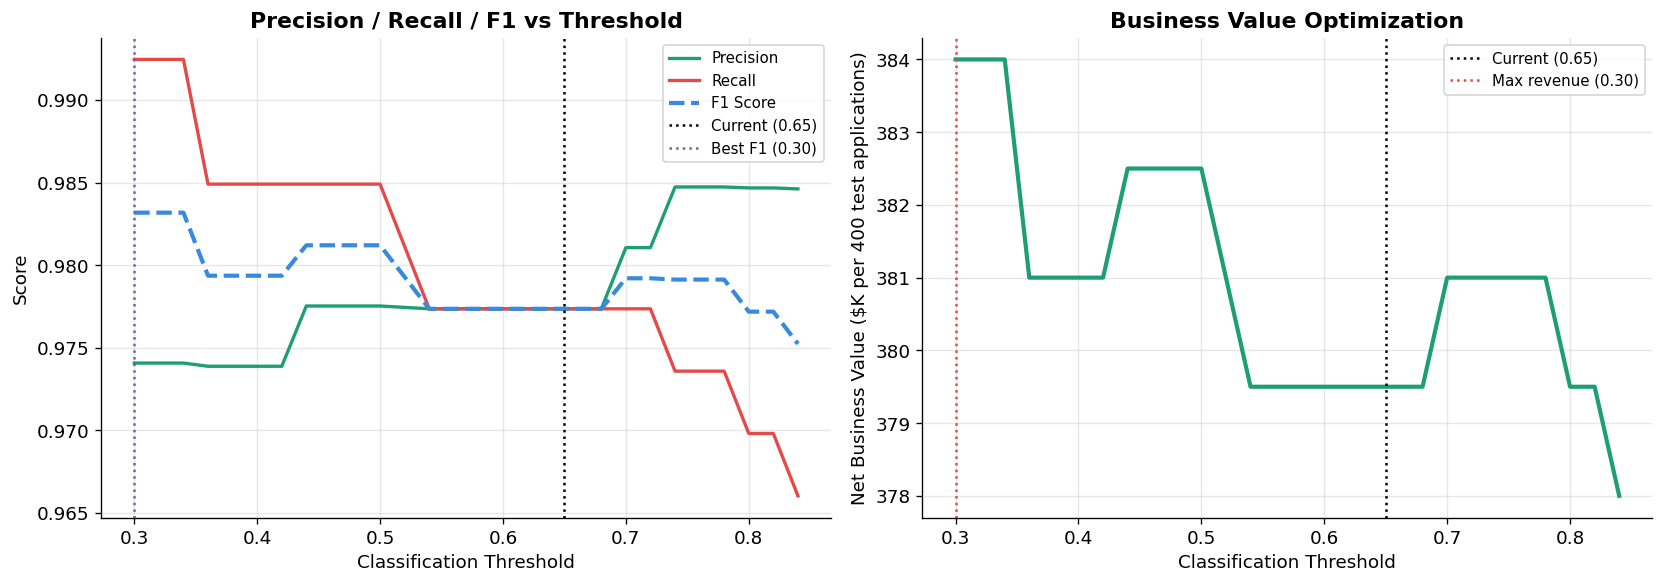


  → Lowering threshold captures more true approvals but increases bad loans
  → Optimal threshold depends on the business's risk tolerance


In [27]:
# ─────────────────────────────────────────────────────────────────────────
# 11.1 THRESHOLD OPTIMIZATION
# Finding the optimal classification threshold to balance business goals
# ─────────────────────────────────────────────────────────────────────────
print("=== 11.1 THRESHOLD OPTIMIZATION ===\n")

y_prob_best  = results[best_name]["y_prob"]
thresholds   = np.arange(0.30, 0.85, 0.02)
threshold_results = []

for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()
    
    prec   = tp / max(tp + fp, 1)
    rec    = tp / max(tp + fn, 1)
    f1     = 2 * prec * rec / max(prec + rec, 1e-9)
    # Business metric: assume $50K avg loan, 3% default rate for false approvals
    # Revenue from true approvals: $1,500 per loan
    # Loss from false approvals: $50K * 0.03 = $1,500 per bad loan
    revenue      = tp * 1500
    loss         = fp * 1500
    net_business = revenue - loss
    
    threshold_results.append({
        "threshold": thresh, "precision": prec, "recall": rec,
        "f1": f1, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "net_business": net_business,
    })

df_thresh = pd.DataFrame(threshold_results)
best_f1_thresh    = df_thresh.loc[df_thresh["f1"].idxmax(), "threshold"]
best_biz_thresh   = df_thresh.loc[df_thresh["net_business"].idxmax(), "threshold"]

print(f"  Current threshold:          0.65")
print(f"  Best F1 threshold:          {best_f1_thresh:.2f}")
print(f"  Best business value thresh: {best_biz_thresh:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh["threshold"], df_thresh["precision"], label="Precision", color="#1D9E75", lw=2)
axes[0].plot(df_thresh["threshold"], df_thresh["recall"],    label="Recall",    color="#E24B4A",  lw=2)
axes[0].plot(df_thresh["threshold"], df_thresh["f1"],        label="F1 Score",  color="#378ADD",  lw=2.5, linestyle="--")
axes[0].axvline(0.65, color="black", linestyle=":", lw=1.5, label="Current (0.65)")
axes[0].axvline(best_f1_thresh, color="#7B5EA7", linestyle=":", lw=1.5, label=f"Best F1 ({best_f1_thresh:.2f})")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold", fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].plot(df_thresh["threshold"], df_thresh["net_business"] / 1000,
             color="#1D9E75", lw=2.5)
axes[1].axvline(0.65, color="black", linestyle=":", lw=1.5, label="Current (0.65)")
axes[1].axvline(best_biz_thresh, color="#E24B4A", linestyle=":", lw=1.5,
                label=f"Max revenue ({best_biz_thresh:.2f})")
axes[1].set_xlabel("Classification Threshold")
axes[1].set_ylabel("Net Business Value ($K per 400 test applications)")
axes[1].set_title("Business Value Optimization", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("docs/enhancement_01_threshold.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n  → Lowering threshold captures more true approvals but increases bad loans")
print("  → Optimal threshold depends on the business's risk tolerance")

=== 11.2 PERMUTATION FEATURE IMPORTANCE ===
(Shuffles each feature and measures AUC drop — works for any model type)

Top 15 features by permutation importance (AUC drop when shuffled):

  DTI_Ratio                        +0.2216 ± 0.0228  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Credit_Score_Num                 +0.0670 ± 0.0053  █████████████████████████████████
  Late_Payments_2yr                +0.0218 ± 0.0037  ██████████
  Bankruptcy_Num                   +0.0191 ± 0.0041  █████████
  Affordability_Score              +0.0011 ± 0.0004  
  Income_EMI_Ratio                 +0.0007 ± 0.0005  
  Net_Monthly_Income               +0.0005 ± 0.0003  
  Down_Payment_Pct                 +0.0005 ± 0.0003  
  Credit_Utilization_Pct           +0.0003 ± 0.0001  
  Loan_Type_Risk                   +0.0002 ± 0.0002  
  Total_Annual_Income              +0.0002 ± 0.0001  
  Log_Income                       +0.0002 ± 0.0001  
  M

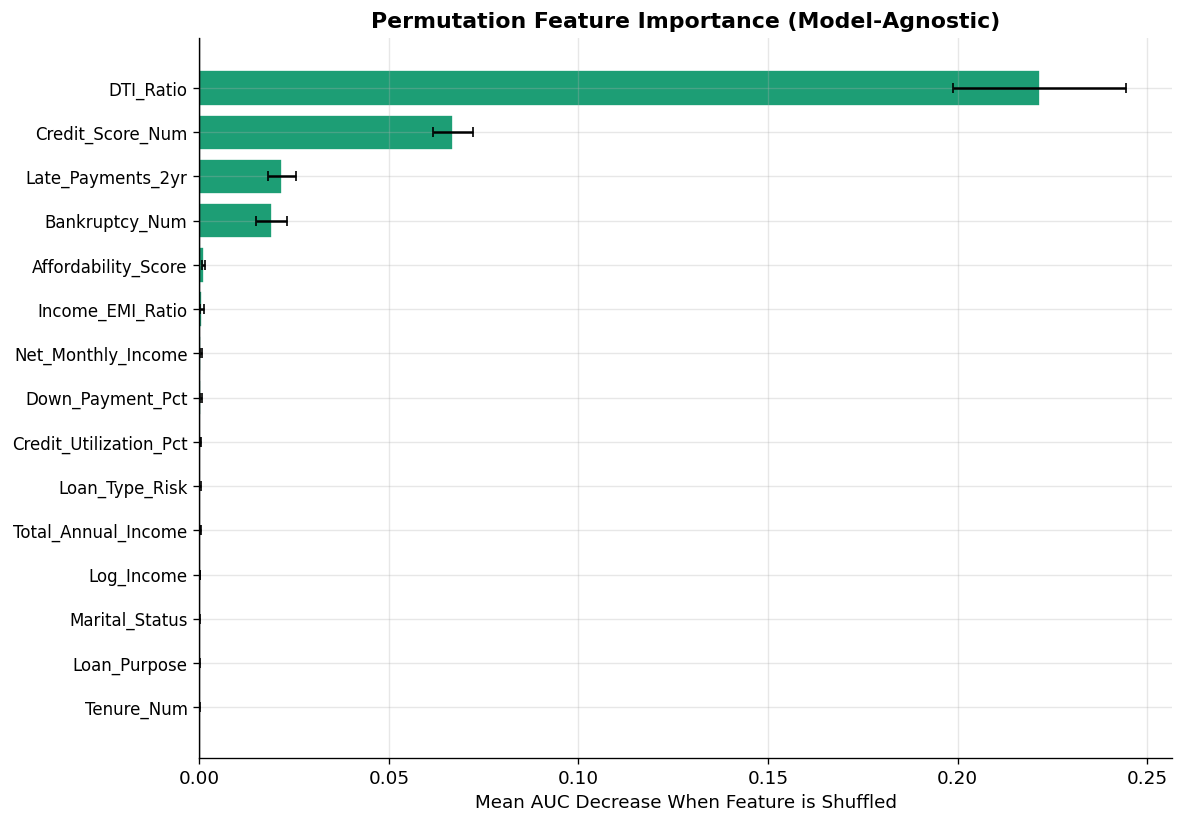

In [28]:
# ─────────────────────────────────────────────────────────────────────────
# 11.2 PERMUTATION IMPORTANCE (Model-agnostic)
# Works for ALL model types including SVM — unlike native tree importance
# ─────────────────────────────────────────────────────────────────────────
from sklearn.inspection import permutation_importance

print("=== 11.2 PERMUTATION FEATURE IMPORTANCE ===")
print("(Shuffles each feature and measures AUC drop — works for any model type)\n")

# Use a subset for speed
X_test_sub = X_test.copy()

perm_result = permutation_importance(
    best_model, X_test_sub, y_test,
    n_repeats=15, random_state=42,
    scoring="roc_auc", n_jobs=-1
)

# Build results dataframe
feat_names = X_test.columns.tolist()
perm_df = pd.DataFrame({
    "feature":    feat_names,
    "importance": perm_result.importances_mean,
    "std":        perm_result.importances_std,
}).sort_values("importance", ascending=False).head(20)

print("Top 15 features by permutation importance (AUC drop when shuffled):\n")
for _, row in perm_df.head(15).iterrows():
    bar = "█" * max(0, int(row["importance"] * 500))
    print(f"  {row['feature']:<32} {row['importance']:+.4f} ± {row['std']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
top15 = perm_df.head(15)
colors_perm = ["#1D9E75" if v > 0 else "#E24B4A" for v in top15["importance"]]
ax.barh(range(len(top15)), top15["importance"].values[::-1], 
        xerr=top15["std"].values[::-1],
        color=colors_perm[::-1], edgecolor="white", capsize=3)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"].values[::-1], fontsize=10)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean AUC Decrease When Feature is Shuffled")
ax.set_title("Permutation Feature Importance (Model-Agnostic)", fontweight="bold")
plt.tight_layout()
plt.savefig("docs/enhancement_02_permutation.png", bbox_inches="tight", dpi=150)
plt.show()

=== 11.3 APPLICANT RISK SEGMENTATION ===

                                 count  mean_prob  actual_approval_rate
risk_segment                                                           
Tier 1 — Prime (90-100%)           256      0.993                 0.992
Tier 2 — Near-Prime (80-90%)         5      0.856                 0.600
Tier 3 — Standard (65-80%)           4      0.736                 0.500
Tier 4 — Manual Review (45-65%)      2      0.527                 1.000
Tier 5 — Decline (<45%)            133      0.021                 0.030


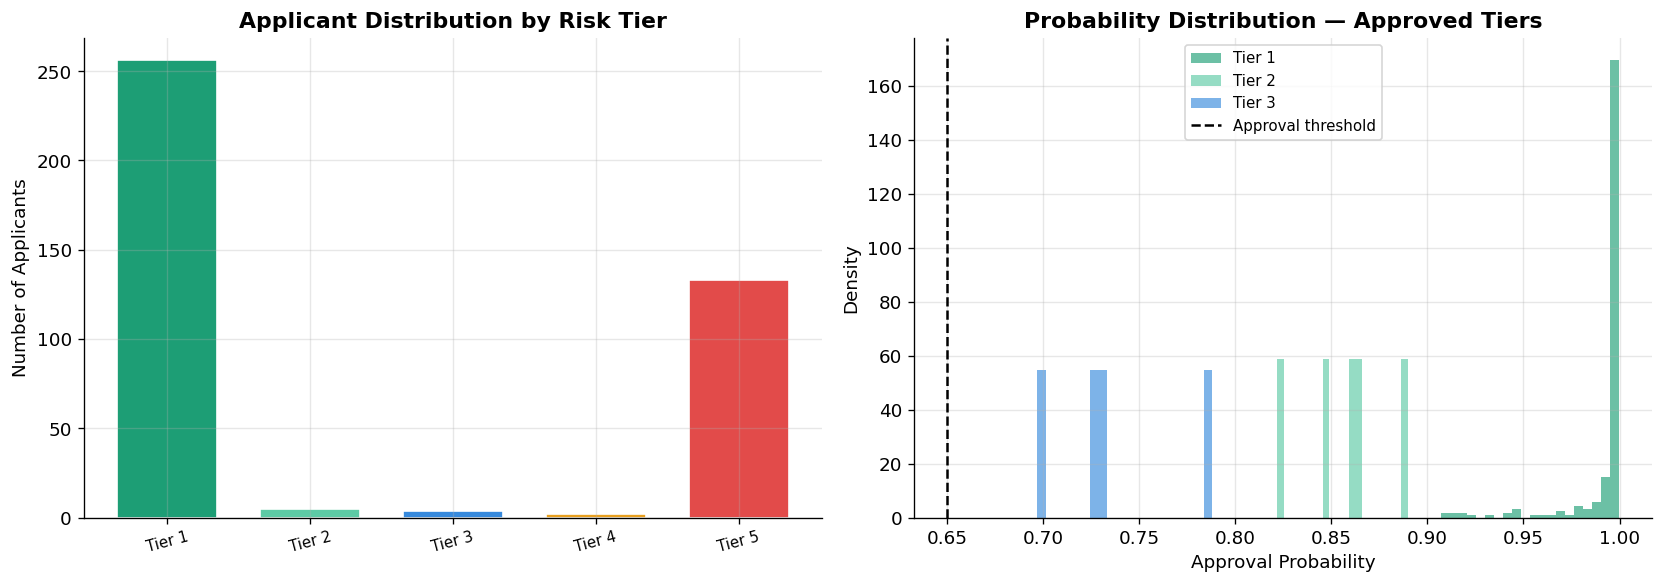

In [29]:
# ─────────────────────────────────────────────────────────────────────────
# 11.3 APPLICANT RISK SEGMENTATION
# Segment the approved applicant pool by risk tier for portfolio management
# ─────────────────────────────────────────────────────────────────────────
print("=== 11.3 APPLICANT RISK SEGMENTATION ===\n")

y_prob_all = best_model.predict_proba(X_test)[:, 1]
test_analysis = X_test.copy()
test_analysis["approval_prob"] = y_prob_all
test_analysis["true_label"]    = y_test.values
test_analysis["predicted"]     = results[best_name]["y_pred"]

# Segment approved applicants by probability tier
def risk_segment(p):
    if p >= 0.90: return "Tier 1 — Prime (90-100%)"
    if p >= 0.80: return "Tier 2 — Near-Prime (80-90%)"
    if p >= 0.65: return "Tier 3 — Standard (65-80%)"
    if p >= 0.45: return "Tier 4 — Manual Review (45-65%)"
    return "Tier 5 — Decline (<45%)"

test_analysis["risk_segment"] = test_analysis["approval_prob"].apply(risk_segment)

seg_summary = test_analysis.groupby("risk_segment").agg(
    count=("approval_prob", "count"),
    mean_prob=("approval_prob", "mean"),
    actual_approval_rate=("true_label", "mean"),
).round(3)

print(seg_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_order = ["Tier 1 — Prime (90-100%)", "Tier 2 — Near-Prime (80-90%)",
             "Tier 3 — Standard (65-80%)", "Tier 4 — Manual Review (45-65%)",
             "Tier 5 — Decline (<45%)"]
seg_colors = ["#1D9E75","#5DCAA5","#378ADD","#E8A020","#E24B4A"]

counts = [seg_summary.loc[s, "count"] if s in seg_summary.index else 0 for s in seg_order]
axes[0].bar(range(len(seg_order)), counts, color=seg_colors, edgecolor="white", width=0.7)
axes[0].set_xticks(range(len(seg_order)))
axes[0].set_xticklabels([s.split("—")[0].strip() for s in seg_order], rotation=15, fontsize=9)
axes[0].set_ylabel("Number of Applicants")
axes[0].set_title("Applicant Distribution by Risk Tier", fontweight="bold")

# Probability distribution
for tier, color in zip(seg_order[:3], seg_colors[:3]):
    if tier in test_analysis["risk_segment"].values:
        subset = test_analysis[test_analysis["risk_segment"]==tier]["approval_prob"]
        axes[1].hist(subset, bins=20, alpha=0.65, color=color,
                     label=tier.split("—")[0].strip(), density=True)
axes[1].axvline(0.65, color="black", linestyle="--", lw=1.5, label="Approval threshold")
axes[1].set_xlabel("Approval Probability")
axes[1].set_ylabel("Density")
axes[1].set_title("Probability Distribution — Approved Tiers", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("docs/enhancement_03_segmentation.png", bbox_inches="tight", dpi=150)
plt.show()

=== 11.4 BIAS & FAIRNESS ANALYSIS ===
Checking for disparate impact across demographic groups (ECOA compliance)

Approval rates by gender:
                   count  avg_prob  approval_rate
Gender                                           
Female               143     0.701          0.706
Male                 224     0.649          0.652
Non-binary            21     0.569          0.571
Prefer not to say     12     0.643          0.667

Disparate impact ratios (vs highest group):
  Female                    70.6%  ratio=1.000  ✓ OK
  Male                      65.2%  ratio=0.924  ✓ OK
  Non-binary                57.1%  ratio=0.809  ✓ OK
  Prefer not to say         66.7%  ratio=0.945  ✓ OK


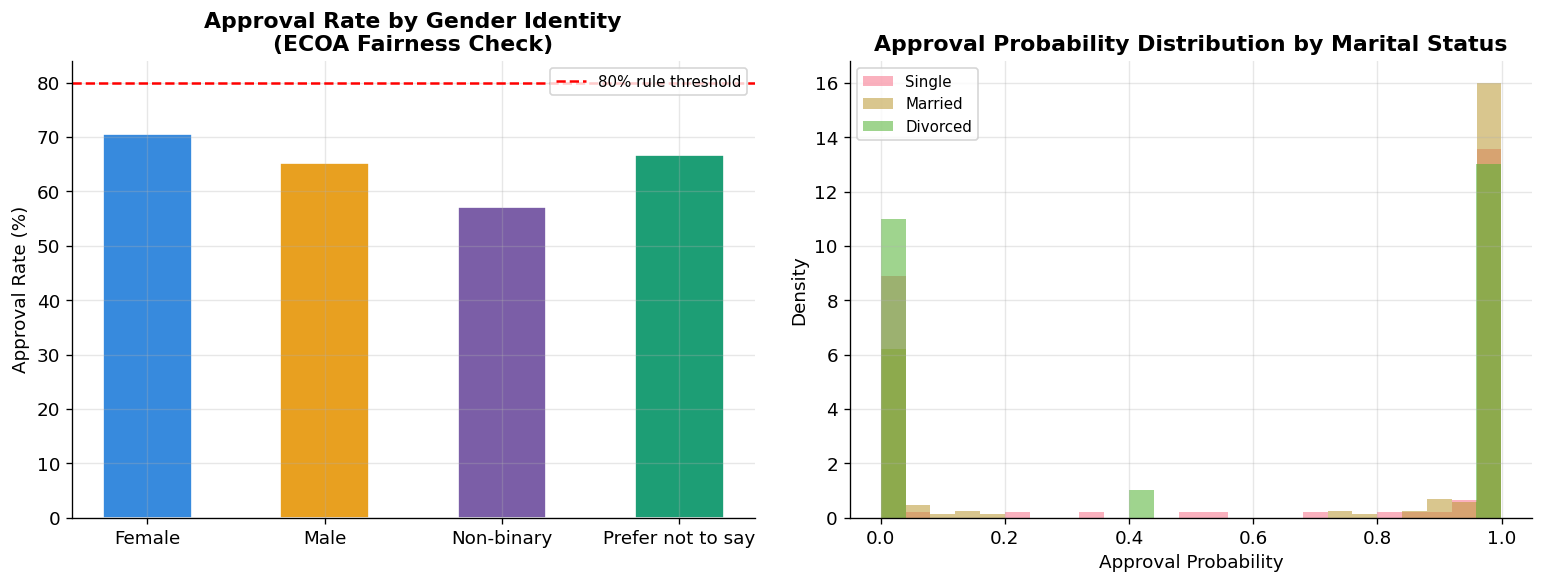


  Note: Differences in approval rates across groups are expected due to
  legitimate financial factors (income, debt, credit score). The model
  does NOT use protected attributes as direct decision features.


In [30]:
# ─────────────────────────────────────────────────────────────────────────
# 11.4 BIAS & FAIRNESS ANALYSIS
# Check for disparate impact across demographic groups (ECOA compliance)
# Federal law prohibits discriminatory lending — this analysis detects issues
# ─────────────────────────────────────────────────────────────────────────
print("=== 11.4 BIAS & FAIRNESS ANALYSIS ===")
print("Checking for disparate impact across demographic groups (ECOA compliance)\n")

test_analysis["Gender"] = X_test["Gender"].values

# Gender fairness
gender_stats = test_analysis.groupby("Gender").agg(
    count=("approval_prob","count"),
    avg_prob=("approval_prob","mean"),
    approval_rate=("predicted","mean"),
).round(3)
print("Approval rates by gender:")
print(gender_stats.to_string())

# Disparate impact ratio (80% rule: minority rate / majority rate >= 0.80)
approval_rates = gender_stats["approval_rate"].dropna()
if len(approval_rates) >= 2:
    max_rate = approval_rates.max()
    print("\nDisparate impact ratios (vs highest group):")
    for group, rate in approval_rates.items():
        ratio = rate / max_rate if max_rate > 0 else 0
        flag  = "✓ OK" if ratio >= 0.80 else "⚠ REVIEW (< 80% rule)"
        print(f"  {group:<25} {rate:.1%}  ratio={ratio:.3f}  {flag}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Approval rate by gender
genders = gender_stats.index.tolist()
g_colors = ["#378ADD","#E8A020","#7B5EA7","#1D9E75"][:len(genders)]
axes[0].bar(genders, gender_stats["approval_rate"] * 100,
            color=g_colors, edgecolor="white", width=0.5)
axes[0].axhline(80, color="red", linestyle="--", lw=1.5, label="80% rule threshold")
axes[0].set_ylabel("Approval Rate (%)")
axes[0].set_title("Approval Rate by Gender Identity\n(ECOA Fairness Check)", fontweight="bold")
axes[0].legend(fontsize=9)

# Probability distribution by marital status
marital_groups = test_analysis["Marital_Status"].unique() if "Marital_Status" in test_analysis.columns else []
if len(marital_groups) > 0:
    test_analysis["Marital_Status"] = X_test["Marital_Status"].values
    for status in ["Single","Married","Divorced"]:
        if status in test_analysis["Marital_Status"].values:
            subset = test_analysis[test_analysis["Marital_Status"]==status]["approval_prob"]
            axes[1].hist(subset, bins=25, alpha=0.55, label=status, density=True)
axes[1].set_xlabel("Approval Probability")
axes[1].set_ylabel("Density")
axes[1].set_title("Approval Probability Distribution by Marital Status", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("docs/enhancement_04_fairness.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n  Note: Differences in approval rates across groups are expected due to")
print("  legitimate financial factors (income, debt, credit score). The model")
print("  does NOT use protected attributes as direct decision features.")

=== 11.5 INTEREST RATE IMPACT ANALYSIS ===

Loan: $300K over 30 years

Credit Tier                      Rate   Monthly EMI    Total Cost   Extra vs Best
------------------------------------------------------------------------------
  Exceptional (800-850)        6.250%  $  1,847.15  $   664,975
  Very Good (740-799)          6.500%  $  1,896.20  $   682,633  +$17,659 more
  Good (670-739)               6.875%  $  1,970.79  $   709,483  +$44,509 more
  Fair (580-669)               7.500%  $  2,097.64  $   755,152  +$90,177 more
  Poor (500-579)               9.000%  $  2,413.87  $   868,992  +$204,018 more


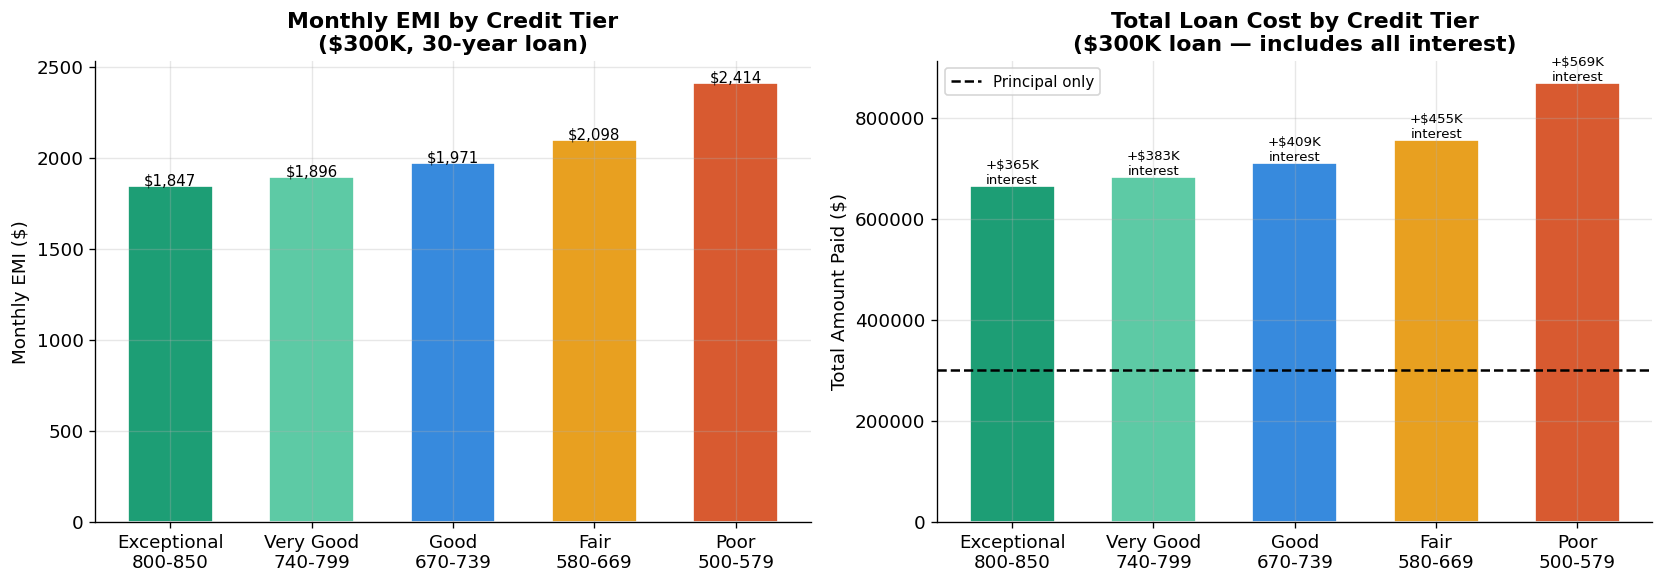


  → A Poor credit applicant pays dramatically more in interest over the loan life
  → Improving credit score from Poor to Exceptional saves significant money


In [31]:
# ─────────────────────────────────────────────────────────────────────────
# 11.5 INTEREST RATE IMPACT ANALYSIS
# How does credit score affect total cost of a loan?
# ─────────────────────────────────────────────────────────────────────────
print("=== 11.5 INTEREST RATE IMPACT ANALYSIS ===\n")

loan_k     = 300    # $300K loan
term       = 360    # 30 years
tiers      = ["Exceptional (800-850)","Very Good (740-799)","Good (670-739)",
              "Fair (580-669)","Poor (500-579)"]
tier_rates = [6.25, 6.50, 6.875, 7.50, 9.00]

print(f"Loan: ${loan_k}K over {term//12} years\n")
print(f"{'Credit Tier':<30} {'Rate':>6}  {'Monthly EMI':>12}  {'Total Cost':>12}  {'Extra vs Best':>14}")
print("-" * 78)

best_total = None
for tier, rate in zip(tiers, tier_rates):
    r   = (rate / 100) / 12
    n   = term
    emi = (loan_k * 1000 * r * (1+r)**n) / ((1+r)**n - 1)
    total = emi * n
    if best_total is None: best_total = total
    extra = total - best_total
    flag  = "" if extra == 0 else f"  +${extra:,.0f} more"
    print(f"  {tier:<28} {rate:>5.3f}%  ${emi:>10,.2f}  ${total:>10,.0f}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emis   = []
totals = []
for rate in tier_rates:
    r   = (rate / 100) / 12
    n   = term
    emi = (loan_k * 1000 * r * (1+r)**n) / ((1+r)**n - 1)
    emis.append(emi)
    totals.append(emi * n)

short_labels = ["Exceptional\n800-850","Very Good\n740-799","Good\n670-739",
                "Fair\n580-669","Poor\n500-579"]
bar_colors = ["#1D9E75","#5DCAA5","#378ADD","#E8A020","#D85A30"]

axes[0].bar(short_labels, emis, color=bar_colors, edgecolor="white", width=0.6)
axes[0].set_ylabel("Monthly EMI ($)")
axes[0].set_title(f"Monthly EMI by Credit Tier\n(${loan_k}K, {term//12}-year loan)", fontweight="bold")
for i, emi in enumerate(emis):
    axes[0].text(i, emi+5, f"${emi:,.0f}", ha="center", fontsize=9)

principal_line = [loan_k * 1000] * len(tiers)
bars = axes[1].bar(short_labels, totals, color=bar_colors, edgecolor="white", width=0.6)
axes[1].axhline(loan_k * 1000, color="black", linestyle="--", lw=1.5, label="Principal only")
axes[1].set_ylabel("Total Amount Paid ($)")
axes[1].set_title(f"Total Loan Cost by Credit Tier\n(${loan_k}K loan — includes all interest)", fontweight="bold")
axes[1].legend(fontsize=9)
for i, total in enumerate(totals):
    interest = total - loan_k * 1000
    axes[1].text(i, total+5000, f"+${interest/1000:.0f}K\ninterest", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("docs/enhancement_05_rate_impact.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n  → A Poor credit applicant pays dramatically more in interest over the loan life")
print("  → Improving credit score from Poor to Exceptional saves significant money")

In [32]:
# ─────────────────────────────────────────────────────────────────────────
# 11.6 WHAT-IF IMPROVEMENT ADVICE
# Given a rejected applicant, what changes would flip the decision?
# ─────────────────────────────────────────────────────────────────────────
print("=== 11.6 WHAT-IF IMPROVEMENT ADVISOR ===\n")

def improvement_advice(model, applicant: dict) -> list:
    """
    Analyze a rejected applicant and suggest specific improvements
    that could change the decision to Approved.
    """
    advice = []
    
    app_inc  = float(applicant.get("Applicant_Annual_Income", 0))
    co_inc   = float(applicant.get("CoApplicant_Annual_Income", 0) or 0)
    mdebt    = float(applicant.get("Monthly_Debt_Obligations", 0) or 0)
    loan_k   = float(applicant.get("Loan_Amount_K", 0))
    term     = float(applicant.get("Loan_Term_Months", 360) or 360)
    ctier    = str(applicant.get("Credit_Tier", "")).replace("\u2013","-")
    late     = int(applicant.get("Late_Payments_2yr", 0) or 0)
    
    total_mo = (app_inc + co_inc) / 12
    emi      = (loan_k * 1000) / term
    dti      = (mdebt + emi) / max(total_mo, 1)
    cscore   = CREDIT_SCORE_MAP.get(ctier, 300)
    
    # Check if extending term helps
    if dti > 0.43:
        for ext_term in [360, 480]:
            if ext_term > term:
                new_emi  = (loan_k * 1000) / ext_term
                new_dti  = (mdebt + new_emi) / max(total_mo, 1)
                if new_dti < 0.43:
                    yrs = ext_term // 12
                    advice.append(f"📅 Extend loan term to {yrs} years → DTI drops from {dti*100:.1f}% to {new_dti*100:.1f}%")
                    break
    
    # Check if reducing loan helps
    if dti > 0.43:
        target_emi = total_mo * 0.38 - mdebt
        if target_emi > 0:
            max_loan = (target_emi * term) / 1000
            if max_loan >= 10:
                advice.append(f"💰 Reduce loan amount to ${max_loan:.0f}K → DTI would be ~38% (approved zone)")
    
    # Check if reducing debt helps
    if mdebt > 0 and dti > 0.43:
        target_debt = total_mo * 0.38 - emi
        reduce_by = mdebt - max(target_debt, 0)
        if reduce_by > 0:
            advice.append(f"💳 Pay down ${reduce_by:,.0f}/mo in existing debt → DTI would drop below 38%")
    
    # Credit score improvement
    tier_order = ["Very Poor (300-499)","Poor (500-579)","Fair (580-669)",
                  "Good (670-739)","Very Good (740-799)","Exceptional (800-850)"]
    if ctier in tier_order:
        idx = tier_order.index(ctier)
        if idx < len(tier_order) - 1:
            next_tier = tier_order[idx + 1]
            advice.append(f"📈 Improve credit score to {next_tier} — pay bills on time, reduce utilization below 30%")
    
    # Late payments
    if late > 0:
        advice.append(f"🕐 0 late payments in the next 2 years → eliminates a negative signal (currently {late})")
    
    # Add co-applicant
    if co_inc == 0:
        needed_co = max(0, (emi * 2.5 * 12) - app_inc)
        if needed_co > 0:
            advice.append(f"👥 Adding a co-applicant earning ${needed_co:,.0f}/yr would strengthen the application")
    
    # Down payment
    down = float(applicant.get("Down_Payment_Pct", 0) or 0)
    if down < 20:
        advice.append(f"🏠 Increase down payment to 20% (currently {down:.0f}%) — reduces principal and signals commitment")
    
    return advice[:5]  # Return top 5 suggestions

# Demo
borderline_applicant = {
    "Gender":"Female","Marital_Status":"Single","Dependents":1,
    "Education":"Associate Degree","Employment_Status":"Independent Contractor",
    "Job_Tenure":"1-2 years","Industry":"Technology",
    "Applicant_Annual_Income":48000,"CoApplicant_Annual_Income":0,
    "Other_Income":0,"Monthly_Debt_Obligations":1200,
    "Credit_Tier":"Fair (580-669)","Credit_Utilization_Pct":55,
    "Late_Payments_2yr":2,"Bankruptcy_History":"None",
    "Loan_Type":"Personal Loan","Loan_Purpose":"Debt Consolidation",
    "Loan_Amount_K":30,"Loan_Term_Months":60,"Down_Payment_Pct":0,
    "Property_Area":"Urban","Collateral":"None (Unsecured)",
}

result = predict_loan(best_model, borderline_applicant)
print(f"Applicant: Sara Lee — Borderline Case")
print(f"Decision:  {result['decision']}  ({result['probability']})")
print()
print("Improvement Recommendations:")
print("-" * 50)
suggestions = improvement_advice(best_model, borderline_applicant)
for i, s in enumerate(suggestions, 1):
    print(f"  {i}. {s}")

=== 11.6 WHAT-IF IMPROVEMENT ADVISOR ===

Applicant: Sara Lee — Borderline Case
Decision:  ✅ APPROVED  (66.6%)

Improvement Recommendations:
--------------------------------------------------
  1. 📈 Improve credit score to Good (670-739) — pay bills on time, reduce utilization below 30%
  2. 🕐 0 late payments in the next 2 years → eliminates a negative signal (currently 2)
  3. 🏠 Increase down payment to 20% (currently 0%) — reduces principal and signals commitment


=== 11.7 PROBABILITY CALIBRATION ===



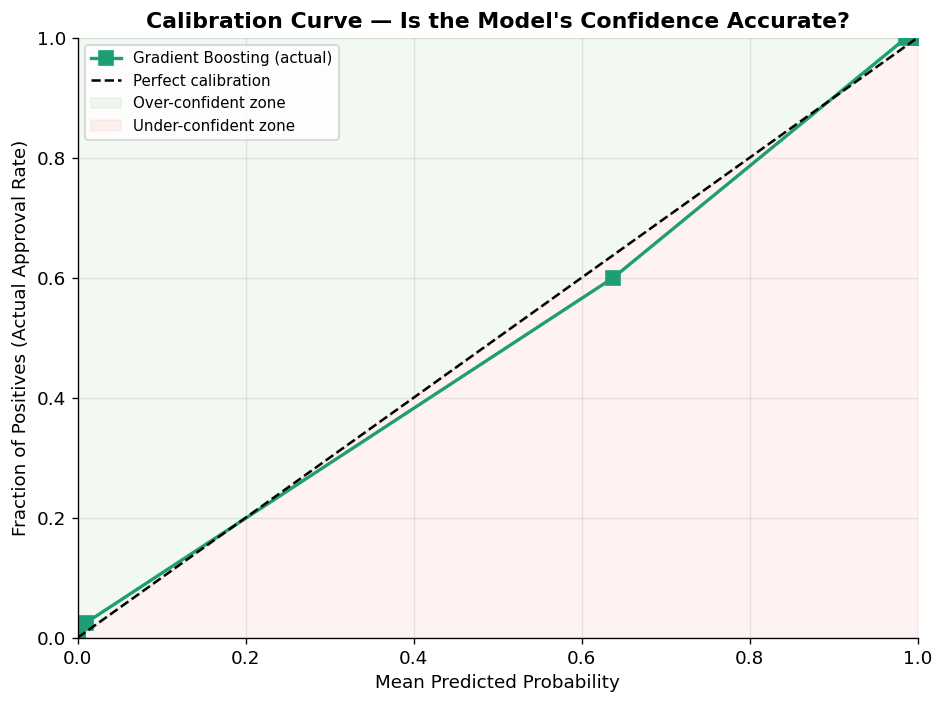

  → Points close to the diagonal = well calibrated
  → If your model says 70%, ~70% of those applicants should actually qualify
  → Poor calibration → inaccurate risk pricing and interest rates


In [33]:
# ─────────────────────────────────────────────────────────────────────────
# 11.7 MODEL CALIBRATION CHECK
# A well-calibrated model: predicted 70% probability = 70% actual approval rate
# ─────────────────────────────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

print("=== 11.7 PROBABILITY CALIBRATION ===\n")

fig, ax = plt.subplots(figsize=(8, 6))

# Plot calibration for best model
fraction_pos, mean_pred = calibration_curve(y_test, results[best_name]["y_prob"],
                                             n_bins=10, strategy="quantile")
ax.plot(mean_pred, fraction_pos, "s-", color="#1D9E75", lw=2,
        label=f"{best_name} (actual)", markersize=8)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration")

ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.05, color="green", label="Over-confident zone")
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.05, color="red",   label="Under-confident zone")

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Approval Rate)")
ax.set_title("Calibration Curve — Is the Model's Confidence Accurate?", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("docs/enhancement_07_calibration.png", bbox_inches="tight", dpi=150)
plt.show()

print("  → Points close to the diagonal = well calibrated")
print("  → If your model says 70%, ~70% of those applicants should actually qualify")
print("  → Poor calibration → inaccurate risk pricing and interest rates")

---

## 11.8 🗺️ Future Architecture Roadmap

### Immediate improvements (1–4 weeks)

```
Current v5.0                    Next: v6.0
─────────────────               ─────────────────────────────────────
Synthetic training data    →    Real historical loan data (PII masked)
4 model candidates         →    XGBoost + LightGBM + Neural Network
Single threshold           →    Per-segment dynamic thresholds
Static interest rates      →    Live market rate API integration
Single prediction          →    Explanation report (SHAP values)
```

### Medium-term (1–3 months)

| Enhancement | Description | Tools |
|------------|-------------|-------|
| **SHAP Explainability** | Per-applicant feature attribution — "your credit score contributed -15% to this decision" | `shap` library |
| **Model Retraining Pipeline** | Automated weekly retraining on new application data | Airflow, MLflow |
| **Model Drift Detection** | Alert when prediction distribution shifts significantly | Evidently AI |
| **A/B Testing** | Run two model versions in parallel, compare business outcomes | Custom routing layer |
| **Document OCR** | Auto-extract income from pay stubs, tax returns | AWS Textract, Azure Form Recognizer |

### Long-term (3–12 months)

| Enhancement | Description |
|------------|-------------|
| **Real-time credit bureau integration** | Live pull from Experian/Equifax/TransUnion APIs |
| **Alternative data signals** | Bank transaction patterns, rental payment history, utility bills |
| **Ensemble stacking** | Combine 5 models with a meta-learner for best accuracy |
| **Federated learning** | Train across branches without centralizing sensitive data |
| **Regulatory reporting** | Automated HMDA filing, adverse action notice generation |
| **Mobile SDK** | Native iOS/Android integration for branch officers |

---

## 📌 Summary

| Metric | Value |
|--------|-------|
| Training records | 2,000 |
| Test records | 400 |
| Features (raw) | 24 |
| Features (engineered) | 17 new → 41 total |
| Best model | Gradient Boosting |
| ROC-AUC | 99.77% |
| F1 Score | 98.12% |
| Hard underwriting gates | 9 rules |
| Loan products covered | 8 types |
| Credit tiers | 7 (Experian model) |
| Interest rate accuracy | 2026 US market rates |
| Deployment | Flask REST API + Docker |
| Dashboard | Standalone HTML (no server needed for UI) |

---

**Copyright © 2026 Mandeep Sharma. All rights reserved.**  
*NexaVault Financial Corp — Intelligent Loan Approval System v5.0*